# Career Atlas: Data Wrangling and EDA

This notebook downloads, cleans, merges, validates, and explores the 2020-2024 occupation–metro dataset.

This version includes three data sources:

- BLS OEWS occupation–metro wage and employment data
- Census ACS 5-year metro-level rent, income, and population data
- BEA Regional Price Parities metro-level cost-of-living data

Final output:

- `data/processed/career_city_fit_2020_2024.csv`
- `data/processed/career_city_fit_2020_2024.parquet`

## Project framing

In this notebook, we build the data foundation for Career Atlas. The goal is to create a clean occupation-by-metro-by-year dataset that can answer a practical question:

> For a given career, which U.S. metro areas offer the best balance of wages, rent, cost of living, and labor-market opportunity?

We use official public data sources because the project depends on data that is free, legal, reproducible, and large enough for downstream modeling. The three core sources are:

- **BLS OEWS** for occupation-specific wages, employment, jobs per 1,000 jobs, and location quotient.
- **ACS 5-year data** for metro-level rent, household income, and population.
- **BEA Regional Price Parities** for metro-level cost-of-living adjustment.

The final unit of analysis is:

> one occupation, in one metro area, in one year.

This structure lets us compare not just cities, but **career-city pairs**. That distinction matters because the same metro can be affordable for one occupation and unaffordable for another.

## 1. Setup

In [32]:
%pip install -q polars pandas openpyxl requests matplotlib pyarrow duckdb scipy


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [33]:
from __future__ import annotations

import json
import os
import re
import zipfile
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import requests
from IPython.display import display

pl.Config.set_tbl_rows(12)
pl.Config.set_tbl_cols(18)
pl.Config.set_fmt_str_lengths(90)

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
FIG_DIR = PROJECT_ROOT / "figures"

for path in [
    RAW_DIR / "bls",
    RAW_DIR / "acs",
    RAW_DIR / "bea",
    INTERIM_DIR,
    PROCESSED_DIR,
    FIG_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

USER_AGENT = "career-city-fit-notebook/3.0 (education project)"
SESSION = requests.Session()
SESSION.headers.update({"User-Agent": USER_AGENT})

In [34]:
YEARS = list(range(2020, 2025))

# Use ACS 5-year for all years so 2020 is supported consistently.
ACS_PRODUCT = "acs5"

CENSUS_API_KEY = os.getenv("CENSUS_API_KEY")

STANDARD_FULL_TIME_HOURS = 2080

BEA_RPP_ZIP_PATH = RAW_DIR / "bea" / "MARPP.zip"
BEA_RPP_RAW_CSV_PATH = RAW_DIR / "bea" / "MARPP_raw.csv"
BEA_RPP_CLEAN_CSV_PATH = INTERIM_DIR / "bea_rpp_2020_2024_metro.csv"

# The current downloadable BEA regional CSV archive usually works through the first URL.
# The historical URLs are fallback candidates in case BEA changes the current download route.
BEA_RPP_ZIP_URLS = [
    "https://apps.bea.gov/regional/zip/MARPP.zip",
    "https://apps.bea.gov/regional/histdata/releases/0226rpi/MARPP.zip",
    "https://apps.bea.gov/regional/histdata/releases/1225rpi/MARPP.zip",
    "https://apps.bea.gov/regional/histdata/releases/0920rpi/MARPP.zip",
]

FINAL_DATASET_CSV_PATH = PROCESSED_DIR / "career_city_fit_2020_2024.csv"
FINAL_DATASET_PARQUET_PATH = PROCESSED_DIR / "career_city_fit_2020_2024.parquet"
YEARLY_BUILD_SUMMARY_CSV_PATH = INTERIM_DIR / "yearly_build_summary.csv"

IMPORTANT_FINAL_COLUMNS = [
    "year",
    "cbsa_code",
    "bls_msa_name",
    "acs_area_name",
    "bea_area_name",
    "prim_state",
    "occ_code",
    "occ_title",
    "o_group",
    "tot_emp",
    "emp_prse",
    "jobs_1000",
    "loc_quotient",
    "h_mean",
    "a_mean",
    "h_median",
    "a_median",
    "wage_annual_mean",
    "wage_annual_median",
    "mean_wage_source",
    "median_wage_source",
    "median_gross_rent",
    "annual_rent",
    "median_household_income",
    "population",
    "rpp_all_items",
    "rpp_goods",
    "rpp_services_housing",
    "rpp_services_rents",
    "rpp_services_other",
    "implicit_regional_price_deflator",
    "rpp_all_items_index",
    "rpp_services_housing_index",
    "rpp_services_rents_index",
    "real_wage_annual_mean",
    "real_wage_annual_median",
    "real_median_household_income",
    "real_income_after_rent_mean",
    "real_income_after_rent_median",
    "rent_to_mean_wage_ratio",
    "rent_to_median_wage_ratio",
    "mean_wage_to_rent_ratio",
    "median_wage_to_rent_ratio",
    "cost_adjusted_rent_burden_mean",
    "cost_adjusted_rent_burden_median",
    "annual_mean_wage_to_metro_income_ratio",
    "annual_median_wage_to_metro_income_ratio",
    "log_tot_emp",
    "low_employment_flag",
    "high_lq_flag",
    "has_valid_mean_affordability",
    "has_valid_median_affordability",
    "has_valid_rpp",
    "has_valid_real_wage",
]

### Setup interpretation

The setup cell creates the directory structure and imports the packages needed for the full pipeline. We organize the project into raw, interim, processed, modeling, and figure folders so that the workflow is reproducible and easier to debug.

This matters because the notebook is doing several different jobs: downloading raw data, cleaning source-specific files, merging datasets, validating coverage, producing EDA visuals, and exporting final artifacts for the modeling notebook. Keeping those outputs separated makes it much easier to trace where each result came from.

## 2. Helper Functions

In [35]:
def year_paths(year: int) -> dict[str, Path]:
    yy = str(year)[-2:]

    return {
        "bls_zip": RAW_DIR / "bls" / f"oesm{yy}ma.zip",
        "bls_extract_dir": RAW_DIR / "bls" / f"oesm{yy}ma_extracted",
        "bls_raw_csv": RAW_DIR / "bls" / f"oews_{year}_raw.csv",
        "acs_raw_json": RAW_DIR / "acs" / f"acs_{year}_{ACS_PRODUCT}_metro_raw.json",
        "acs_raw_csv": RAW_DIR / "acs" / f"acs_{year}_{ACS_PRODUCT}_metro_raw.csv",
        "acs_clean_csv": INTERIM_DIR / f"acs_{year}_metro_context.csv",
        "bls_clean_csv": INTERIM_DIR / f"oews_{year}_occ_metro.csv",
        "merged_csv": PROCESSED_DIR / f"occ_metro_{year}_merged.csv",
        "unmatched_acs_csv": INTERIM_DIR / f"acs_unmatched_to_bls_{year}.csv",
        "unmatched_bea_csv": INTERIM_DIR / f"bea_unmatched_to_bls_{year}.csv",
    }


def bls_oews_zip_url(year: int) -> str:
    yy = str(year)[-2:]
    return f"https://www.bls.gov/oes/special-requests/oesm{yy}ma.zip"


def acs_base_url(year: int) -> str:
    return f"https://api.census.gov/data/{year}/acs/{ACS_PRODUCT}"


def acs_params() -> dict:
    params = {
        "get": "NAME,B25064_001E,B19013_001E,B01003_001E",
        "for": "metropolitan statistical area/micropolitan statistical area:*",
    }

    if CENSUS_API_KEY:
        params["key"] = CENSUS_API_KEY

    return params


def download_file(
    url: str,
    destination: Path,
    overwrite: bool = False,
    chunk_size: int = 1024 * 1024,
) -> Path:
    destination.parent.mkdir(parents=True, exist_ok=True)

    if destination.exists() and not overwrite:
        print(f"Using existing file: {destination}")
        return destination

    print(f"Downloading: {url}")

    with SESSION.get(url, stream=True, timeout=180) as response:
        response.raise_for_status()

        with open(destination, "wb") as f:
            for chunk in response.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)

    print(f"Saved: {destination} ({destination.stat().st_size / 1_000_000:.2f} MB)")
    return destination


def sanitize_column_name(name: str) -> str:
    name = str(name).strip().lower()
    name = re.sub(r"[%/]", " ", name)
    name = re.sub(r"[^a-z0-9]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    return name


def sanitize_columns(columns: Iterable[str]) -> list[str]:
    return [sanitize_column_name(c) for c in columns]


def pick_first_existing(columns: list[str], candidates: list[str]) -> str | None:
    for candidate in candidates:
        if candidate in columns:
            return candidate
    return None


def ensure_columns(df: pl.DataFrame, columns: list[str]) -> pl.DataFrame:
    missing = [c for c in columns if c not in df.columns]

    if missing:
        df = df.with_columns([pl.lit(None).alias(c) for c in missing])

    return df


def to_numeric_expr(column_name: str, dtype: pl.DataType = pl.Float64) -> pl.Expr:
    return (
        pl.col(column_name)
        .cast(pl.Utf8)
        .str.replace_all(",", "")
        .str.replace_all(r"[^0-9.\-]", "")
        .replace("", None)
        .cast(dtype, strict=False)
        .alias(column_name)
    )


def remove_negative_sentinel_expr(column_name: str) -> pl.Expr:
    return (
        pl.when(pl.col(column_name) < 0)
        .then(None)
        .otherwise(pl.col(column_name))
        .alias(column_name)
    )


def print_shape(label: str, df: pl.DataFrame) -> None:
    print(f"{label}: {df.height:,} rows × {df.width:,} cols")


def display_pl(df: pl.DataFrame, rows: int = 8) -> None:
    display(df.head(rows).to_pandas())


def read_final_dataset() -> pl.DataFrame:
    df = pl.read_csv(FINAL_DATASET_CSV_PATH, infer_schema_length=5000)

    if "cbsa_code" in df.columns:
        df = df.with_columns(
            pl.col("cbsa_code").cast(pl.Utf8).str.zfill(5).alias("cbsa_code")
        )

    if "occ_code" in df.columns:
        df = df.with_columns(
            pl.col("occ_code").cast(pl.Utf8).alias("occ_code")
        )

    return df

In [36]:
def choose_bls_data_member(zf: zipfile.ZipFile) -> str:
    candidate_infos = []

    for info in zf.infolist():
        name = info.filename
        lower = name.lower()

        if lower.endswith("/"):
            continue

        if not lower.endswith((".xlsx", ".xls", ".csv", ".txt")):
            continue

        if any(
            bad in lower
            for bad in [
                "readme",
                "field_description",
                "field descriptions",
                "layout",
            ]
        ):
            continue

        score = info.file_size

        if "dl" in lower or "data" in lower:
            score += 1_000_000_000

        if lower.endswith((".xlsx", ".xls")):
            score += 100_000_000

        candidate_infos.append((score, info))

    if not candidate_infos:
        raise FileNotFoundError("No usable BLS data file found inside ZIP.")

    chosen_info = max(candidate_infos, key=lambda x: x[0])[1]
    return chosen_info.filename


def extract_bls_zip(year: int, overwrite: bool = False) -> Path:
    paths = year_paths(year)
    paths["bls_extract_dir"].mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(paths["bls_zip"], "r") as zf:
        member = choose_bls_data_member(zf)
        extracted_path = paths["bls_extract_dir"] / member

        if overwrite or not extracted_path.exists():
            print(f"Extracting BLS {year} file: {member}")
            zf.extract(member, path=paths["bls_extract_dir"])
        else:
            print(f"Using existing extracted BLS file: {extracted_path}")

    return extracted_path


def read_bls_raw_file_to_csv(year: int, overwrite: bool = False) -> Path:
    paths = year_paths(year)

    if paths["bls_raw_csv"].exists() and not overwrite:
        print(f"Using existing raw BLS CSV: {paths['bls_raw_csv']}")
        return paths["bls_raw_csv"]

    extracted_path = extract_bls_zip(year, overwrite=overwrite)
    suffix = extracted_path.suffix.lower()

    if suffix in {".xlsx", ".xls"}:
        raw_pd = pd.read_excel(extracted_path, sheet_name=0)
    elif suffix == ".csv":
        raw_pd = pd.read_csv(extracted_path)
    elif suffix == ".txt":
        raw_pd = pd.read_csv(extracted_path, sep=None, engine="python")
    else:
        raise ValueError(f"Unsupported BLS file type: {suffix}")

    raw_pd.to_csv(paths["bls_raw_csv"], index=False)

    print(f"Raw BLS {year} shape: {raw_pd.shape[0]:,} rows × {raw_pd.shape[1]:,} cols")
    print(f"Saved raw BLS CSV: {paths['bls_raw_csv']}")

    return paths["bls_raw_csv"]

In [37]:
def download_acs_year(year: int, overwrite: bool = False) -> Path:
    paths = year_paths(year)

    if paths["acs_raw_csv"].exists() and not overwrite:
        print(f"Using existing raw ACS CSV: {paths['acs_raw_csv']}")
        return paths["acs_raw_csv"]

    print(f"Requesting ACS {year} {ACS_PRODUCT} API data...")

    response = SESSION.get(
        acs_base_url(year),
        params=acs_params(),
        timeout=180,
    )
    response.raise_for_status()

    acs_json = response.json()

    with open(paths["acs_raw_json"], "w", encoding="utf-8") as f:
        json.dump(acs_json, f)

    acs_header = acs_json[0]
    acs_rows = acs_json[1:]

    acs_raw_pd = pd.DataFrame(acs_rows, columns=acs_header)
    acs_raw_pd.to_csv(paths["acs_raw_csv"], index=False)

    print(f"Saved ACS raw JSON: {paths['acs_raw_json']}")
    print(f"Saved ACS raw CSV:  {paths['acs_raw_csv']}")

    return paths["acs_raw_csv"]

In [38]:
def download_bea_rpp_zip(overwrite: bool = False) -> Path:
    BEA_RPP_ZIP_PATH.parent.mkdir(parents=True, exist_ok=True)

    if BEA_RPP_ZIP_PATH.exists() and not overwrite and zipfile.is_zipfile(BEA_RPP_ZIP_PATH):
        print(f"Using existing BEA RPP ZIP: {BEA_RPP_ZIP_PATH}")
        return BEA_RPP_ZIP_PATH

    errors = []

    for url in BEA_RPP_ZIP_URLS:
        try:
            print(f"Trying BEA RPP download: {url}")

            with SESSION.get(url, stream=True, timeout=180) as response:
                response.raise_for_status()

                temp_path = BEA_RPP_ZIP_PATH.with_suffix(".download")

                with open(temp_path, "wb") as f:
                    for chunk in response.iter_content(chunk_size=1024 * 1024):
                        if chunk:
                            f.write(chunk)

            if zipfile.is_zipfile(temp_path):
                temp_path.replace(BEA_RPP_ZIP_PATH)
                print(f"Saved BEA RPP ZIP: {BEA_RPP_ZIP_PATH}")
                return BEA_RPP_ZIP_PATH

            temp_path.unlink(missing_ok=True)
            errors.append(f"{url}: response was not a valid ZIP file")

        except Exception as exc:
            errors.append(f"{url}: {exc}")

    error_text = "\n".join(errors)

    raise RuntimeError(
        "Could not download BEA RPP MARPP.zip from the configured URLs. "
        "You can manually download the BEA MARPP Regional Price Parities by MSA ZIP file "
        f"and save it as {BEA_RPP_ZIP_PATH}.\n\nAttempted URLs:\n{error_text}"
    )


def choose_bea_rpp_member(zf: zipfile.ZipFile) -> str:
    candidate_infos = []

    for info in zf.infolist():
        lower = info.filename.lower()

        if lower.endswith("/"):
            continue

        if not lower.endswith((".csv", ".txt")):
            continue

        score = info.file_size

        if "marpp" in lower:
            score += 1_000_000_000

        if "rpp" in lower:
            score += 100_000_000

        candidate_infos.append((score, info))

    if not candidate_infos:
        raise FileNotFoundError("No usable BEA RPP CSV/TXT file found inside ZIP.")

    return max(candidate_infos, key=lambda x: x[0])[1].filename


def read_bea_rpp_raw_file_to_csv(overwrite: bool = False) -> Path:
    if BEA_RPP_RAW_CSV_PATH.exists() and not overwrite:
        print(f"Using existing raw BEA RPP CSV: {BEA_RPP_RAW_CSV_PATH}")
        return BEA_RPP_RAW_CSV_PATH

    download_bea_rpp_zip(overwrite=overwrite)

    with zipfile.ZipFile(BEA_RPP_ZIP_PATH, "r") as zf:
        member = choose_bea_rpp_member(zf)
        print(f"Reading BEA RPP file from ZIP: {member}")

        with zf.open(member) as f:
            try:
                raw_pd = pd.read_csv(f, dtype=str, encoding="utf-8")
            except UnicodeDecodeError:
                f.seek(0)
                raw_pd = pd.read_csv(f, dtype=str, encoding="latin1")

    raw_pd.to_csv(BEA_RPP_RAW_CSV_PATH, index=False)

    print(f"Raw BEA RPP shape: {raw_pd.shape[0]:,} rows × {raw_pd.shape[1]:,} cols")
    print(f"Saved raw BEA RPP CSV: {BEA_RPP_RAW_CSV_PATH}")

    return BEA_RPP_RAW_CSV_PATH

## 3. Download Raw Source Data

In [39]:
for year in YEARS:
    print("=" * 90)
    print(f"Downloading BLS and ACS source files for {year}")
    print("=" * 90)

    paths = year_paths(year)

    download_file(bls_oews_zip_url(year), paths["bls_zip"])
    download_acs_year(year)

print("=" * 90)
print("Downloading BEA RPP source file")
print("=" * 90)

download_bea_rpp_zip()
read_bea_rpp_raw_file_to_csv()

print("Finished downloading raw files.")

Using existing file: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/raw/bls/oesm20ma.zip
Using existing raw ACS CSV: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/raw/acs/acs_2020_acs5_metro_raw.csv
Using existing file: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/raw/bls/oesm21ma.zip
Using existing raw ACS CSV: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/raw/acs/acs_2021_acs5_metro_raw.csv
Using existing file: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/raw/bls/oesm22ma.zip
Using existing raw ACS CSV: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/raw/acs/acs_2022_acs5_metro_raw.csv
Using existing file: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/raw/bls/oesm23ma.zip
Using existing raw ACS CSV: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/raw/acs/acs_2023_acs5_metro_raw.csv
Using existing file: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/da

### Why these data sources were chosen

We use BLS OEWS as the main occupation-level source because it directly gives wages and employment by occupation and metro area. That is the backbone of the project.

We use ACS because OEWS does not tell us how expensive a metro area is to live in. ACS median gross rent gives us a simple and interpretable housing-cost measure.

We use BEA Regional Price Parities because rent alone is not the full cost-of-living story. RPP lets us adjust wages and after-rent income for regional price differences, so a dollar in a lower-cost metro is treated differently from a dollar in a higher-cost metro.

Together, these sources let us move from a simple wage comparison to a more realistic career-city comparison.

## 4. Clean ACS Metro Context Data

In [40]:
def clean_acs_year(year: int) -> pl.DataFrame:
    paths = year_paths(year)

    acs_raw = pl.read_csv(paths["acs_raw_csv"], infer_schema_length=0)
    acs_raw.columns = sanitize_columns(acs_raw.columns)

    geo_code_col = pick_first_existing(
        acs_raw.columns,
        [
            "metropolitan_statistical_area_micropolitan_statistical_area",
            "metropolitan_statistical_area",
            "micropolitan_statistical_area",
        ],
    )

    if geo_code_col is None:
        raise KeyError(
            "Could not identify ACS CBSA geography-code column. "
            f"Available columns: {acs_raw.columns}"
        )

    acs_clean = (
        acs_raw
        .rename({
            "name": "acs_area_name",
            geo_code_col: "cbsa_code",
            "b25064_001e": "median_gross_rent",
            "b19013_001e": "median_household_income",
            "b01003_001e": "population",
        })
        .with_columns([
            pl.lit(year).alias("year"),
            pl.col("cbsa_code").cast(pl.Utf8).str.zfill(5).alias("cbsa_code"),
            to_numeric_expr("median_gross_rent", pl.Int64),
            to_numeric_expr("median_household_income", pl.Int64),
            to_numeric_expr("population", pl.Int64),
        ])
        .with_columns([
            remove_negative_sentinel_expr("median_gross_rent"),
            remove_negative_sentinel_expr("median_household_income"),
            remove_negative_sentinel_expr("population"),
        ])
        .with_columns([
            (pl.col("median_gross_rent") * 12).alias("annual_rent"),
        ])
        .select([
            "year",
            "cbsa_code",
            "acs_area_name",
            "median_gross_rent",
            "annual_rent",
            "median_household_income",
            "population",
        ])
        .unique(subset=["year", "cbsa_code"])
        .sort("cbsa_code")
    )

    acs_clean.write_csv(paths["acs_clean_csv"])

    print_shape(f"ACS clean metro context {year}", acs_clean)
    print(f"Saved: {paths['acs_clean_csv']}")

    return acs_clean

The ACS data adds metro-level context that is shared by all occupations in the same metro. The most important ACS variable for this project is median gross rent, which we convert into annual rent:

`annual_rent = median_gross_rent × 12`

This gives us a clear, intuitive housing-cost denominator for every occupation-metro row. Since rent is metro-level, every occupation in the same metro receives the same rent value. That is acceptable for this project because we are comparing broad metro-level affordability, not neighborhood-level or household-specific affordability.

The ACS data also gives median household income and population, which are useful for understanding the broader economic size and context of a metro area.

## 5. Clean BEA RPP Metro Cost-of-Living Data

In [41]:
def bea_rpp_measure_from_description(description: str) -> str | None:
    if description is None:
        return None

    desc = str(description).strip().lower()
    desc = re.sub(r"\s+", " ", desc)

    if "implicit regional price deflator" in desc or desc.startswith("irpd"):
        return "implicit_regional_price_deflator"

    if "all item" in desc:
        return "rpp_all_items"

    if "goods" in desc:
        return "rpp_goods"

    if ("services" in desc and "other" in desc) or "services: other" in desc:
        return "rpp_services_other"

    if "rent" in desc or "housing" in desc:
        return "rpp_services_housing"

    return None


def clean_bea_rpp() -> pl.DataFrame:
    read_bea_rpp_raw_file_to_csv()

    raw_pd = pd.read_csv(BEA_RPP_RAW_CSV_PATH, dtype=str)
    raw_pd.columns = sanitize_columns(raw_pd.columns)

    geo_col = pick_first_existing(
        list(raw_pd.columns),
        [
            "geofips",
            "geo_fips",
            "geo_fips_code",
            "geo_fips_id",
        ],
    )

    name_col = pick_first_existing(
        list(raw_pd.columns),
        [
            "geoname",
            "geo_name",
            "geo_name_description",
            "area_name",
        ],
    )

    desc_col = pick_first_existing(
        list(raw_pd.columns),
        [
            "description",
            "line_description",
            "line_desc",
            "series_description",
        ],
    )

    if geo_col is None:
        raise KeyError(f"Could not identify BEA GeoFIPS column. Available columns: {list(raw_pd.columns)}")

    if name_col is None:
        raise KeyError(f"Could not identify BEA GeoName column. Available columns: {list(raw_pd.columns)}")

    if desc_col is None:
        raise KeyError(f"Could not identify BEA description column. Available columns: {list(raw_pd.columns)}")

    year_cols = [
        c
        for c in raw_pd.columns
        if re.fullmatch(r"\d{4}", str(c)) and int(c) in YEARS
    ]

    if not year_cols:
        raise KeyError(
            f"Could not identify BEA year columns for {YEARS}. Available columns: {list(raw_pd.columns)}"
        )

    keep_cols = [geo_col, name_col, desc_col] + year_cols

    bea_long = (
        raw_pd[keep_cols]
        .melt(
            id_vars=[geo_col, name_col, desc_col],
            value_vars=year_cols,
            var_name="year",
            value_name="rpp_value",
        )
        .copy()
    )

    bea_long["cbsa_code"] = (
        bea_long[geo_col]
        .astype(str)
        .str.extract(r"(\d{5})", expand=False)
        .str.zfill(5)
    )

    bea_long["bea_area_name"] = bea_long[name_col].astype(str).str.strip()
    bea_long["rpp_measure"] = bea_long[desc_col].apply(bea_rpp_measure_from_description)
    bea_long["year"] = pd.to_numeric(bea_long["year"], errors="coerce").astype("Int64")
    bea_long["rpp_value"] = (
        bea_long["rpp_value"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("(NA)", "", regex=False)
        .str.replace("NA", "", regex=False)
    )
    bea_long["rpp_value"] = pd.to_numeric(bea_long["rpp_value"], errors="coerce")

    bea_long = bea_long.dropna(
        subset=["year", "cbsa_code", "rpp_measure", "rpp_value"]
    )

    bea_long = bea_long[
        bea_long["cbsa_code"].str.match(r"^\d{5}$", na=False)
    ]

    bea_pivot = (
        bea_long
        .pivot_table(
            index=["year", "cbsa_code", "bea_area_name"],
            columns="rpp_measure",
            values="rpp_value",
            aggfunc="first",
        )
        .reset_index()
    )

    bea_pivot.columns.name = None

    expected_rpp_cols = [
        "rpp_all_items",
        "rpp_goods",
        "rpp_services_housing",
        "rpp_services_other",
        "implicit_regional_price_deflator",
    ]

    for col in expected_rpp_cols:
        if col not in bea_pivot.columns:
            bea_pivot[col] = pd.NA

    bea_clean = pl.from_pandas(bea_pivot)

    bea_clean = (
        bea_clean
        .with_columns([
            pl.col("year").cast(pl.Int64),
            pl.col("cbsa_code").cast(pl.Utf8).str.zfill(5),
            pl.col("bea_area_name").cast(pl.Utf8),

            *[
                pl.col(c).cast(pl.Float64, strict=False).alias(c)
                for c in expected_rpp_cols
            ],
        ])
        .with_columns([
            pl.col("rpp_services_housing").alias("rpp_services_rents"),
            (pl.col("rpp_all_items") / 100).alias("rpp_all_items_index"),
            (pl.col("rpp_services_housing") / 100).alias("rpp_services_housing_index"),
            (pl.col("rpp_services_housing") / 100).alias("rpp_services_rents_index"),
        ])
        .select([
            "year",
            "cbsa_code",
            "bea_area_name",
            "rpp_all_items",
            "rpp_goods",
            "rpp_services_housing",
            "rpp_services_rents",
            "rpp_services_other",
            "implicit_regional_price_deflator",
            "rpp_all_items_index",
            "rpp_services_housing_index",
            "rpp_services_rents_index",
        ])
        .unique(subset=["year", "cbsa_code"])
        .sort(["year", "cbsa_code"])
    )

    bea_clean.write_csv(BEA_RPP_CLEAN_CSV_PATH)

    print_shape("BEA RPP clean metro context", bea_clean)
    print(f"Saved: {BEA_RPP_CLEAN_CSV_PATH}")

    display(
        bea_clean
        .group_by("year")
        .agg([
            pl.len().alias("n_metros"),
            pl.col("rpp_all_items").is_not_null().sum().alias("metros_with_all_items_rpp"),
            pl.col("rpp_services_housing").is_not_null().sum().alias("metros_with_housing_rpp"),
        ])
        .sort("year")
        .to_pandas()
    )

    return bea_clean

The BEA Regional Price Parities data helps us adjust for regional price levels. An RPP value above 100 means the metro is more expensive than the U.S. average, while an RPP value below 100 means it is less expensive.

The most important transformation is:

`rpp_all_items_index = rpp_all_items / 100`

Then we use this index to create real, cost-adjusted versions of wage and income measures. For example:

`real_wage_annual_median = wage_annual_median / rpp_all_items_index`

This adjustment is central to the project. Without it, a high nominal wage in an expensive metro could look better than it really is, and a moderate wage in a low-cost metro could be undervalued.

## 6. Clean BLS OEWS Occupation–Metro Data

In [42]:
def clean_bls_year(year: int) -> pl.DataFrame:
    paths = year_paths(year)

    read_bls_raw_file_to_csv(year)

    bls_raw = pl.read_csv(
        paths["bls_raw_csv"],
        infer_schema_length=5000,
        ignore_errors=True,
    )
    bls_raw.columns = sanitize_columns(bls_raw.columns)

    expected_bls_cols = [
        "area",
        "area_title",
        "area_type",
        "prim_state",
        "naics",
        "naics_title",
        "i_group",
        "own_code",
        "occ_code",
        "occ_title",
        "o_group",
        "tot_emp",
        "emp_prse",
        "jobs_1000",
        "loc_quotient",
        "pct_total",
        "pct_rpt",
        "h_mean",
        "a_mean",
        "mean_prse",
        "h_pct10",
        "h_pct25",
        "h_median",
        "h_pct75",
        "h_pct90",
        "a_pct10",
        "a_pct25",
        "a_median",
        "a_pct75",
        "a_pct90",
        "annual",
        "hourly",
    ]

    required_cols = ["area", "area_title", "occ_code", "occ_title", "o_group"]
    missing_required = [c for c in required_cols if c not in bls_raw.columns]

    if missing_required:
        raise KeyError(
            f"BLS {year} raw file is missing required columns: {missing_required}. "
            f"Available columns: {bls_raw.columns}"
        )

    bls_raw = ensure_columns(bls_raw, expected_bls_cols)

    text_cols = [
        "area",
        "area_title",
        "area_type",
        "prim_state",
        "naics",
        "naics_title",
        "i_group",
        "own_code",
        "occ_code",
        "occ_title",
        "o_group",
        "annual",
        "hourly",
    ]

    numeric_cols = [
        "tot_emp",
        "emp_prse",
        "jobs_1000",
        "loc_quotient",
        "pct_total",
        "pct_rpt",
        "h_mean",
        "a_mean",
        "mean_prse",
        "h_pct10",
        "h_pct25",
        "h_median",
        "h_pct75",
        "h_pct90",
        "a_pct10",
        "a_pct25",
        "a_median",
        "a_pct75",
        "a_pct90",
    ]

    bls_clean = (
        bls_raw
        .select(expected_bls_cols)
        .with_columns([
            pl.lit(year).alias("year"),
            *[
                pl.col(c).cast(pl.Utf8).str.strip_chars().alias(c)
                for c in text_cols
            ],
        ])
        .with_columns([
            pl.col("i_group").str.to_lowercase().alias("i_group"),
            pl.col("o_group").str.to_lowercase().alias("o_group"),
            pl.col("naics_title").str.to_lowercase().alias("naics_title"),
        ])
        .with_columns([
            *[to_numeric_expr(c, pl.Float64) for c in numeric_cols],
        ])
        .with_columns([
            pl.col("area").str.extract(r"(\d{5})", 1).str.zfill(5).alias("cbsa_code"),
        ])
        .filter(
            pl.col("area_title").is_not_null()
            & pl.col("occ_code").is_not_null()
            & pl.col("occ_title").is_not_null()
            & pl.col("cbsa_code").is_not_null()
        )
        .with_columns([
            pl.col("cbsa_code").cast(pl.Int64, strict=False).alias("cbsa_int"),
        ])
        .filter(pl.col("cbsa_int").is_not_null() & (pl.col("cbsa_int") < 100000))
        .filter(
            ~pl.col("area_title")
            .str.to_lowercase()
            .str.contains("nonmetropolitan")
            .fill_null(False)
        )
    )

    detail_occ_filter = (
        pl.col("o_group").str.contains("detail").fill_null(False)
        | (
            pl.col("occ_code").str.contains(r"^\d{2}-\d{4}$").fill_null(False)
            & ~pl.col("occ_code").str.ends_with("0000").fill_null(False)
        )
    )

    bls_clean = bls_clean.filter(detail_occ_filter)

    cross_industry_filter = (
        pl.col("i_group").str.contains("cross").fill_null(False)
        | pl.col("naics_title").str.contains("cross").fill_null(False)
        | (pl.col("naics") == "000000")
    )

    cross_industry_count = bls_clean.filter(cross_industry_filter).height

    if cross_industry_count > 0:
        bls_clean = bls_clean.filter(cross_industry_filter)
        print(f"BLS {year}: kept cross-industry rows only: {cross_industry_count:,}")
    else:
        print(f"BLS {year}: no cross-industry marker found; keeping detailed occupation rows.")

    bls_clean = (
        bls_clean
        .with_columns([
            pl.col("area_title").alias("bls_msa_name"),

            pl.when(pl.col("a_mean").is_not_null() & (pl.col("a_mean") > 0))
            .then(pl.col("a_mean"))
            .when(pl.col("h_mean").is_not_null() & (pl.col("h_mean") > 0))
            .then(pl.col("h_mean") * STANDARD_FULL_TIME_HOURS)
            .otherwise(None)
            .alias("wage_annual_mean"),

            pl.when(pl.col("a_median").is_not_null() & (pl.col("a_median") > 0))
            .then(pl.col("a_median"))
            .when(pl.col("h_median").is_not_null() & (pl.col("h_median") > 0))
            .then(pl.col("h_median") * STANDARD_FULL_TIME_HOURS)
            .otherwise(None)
            .alias("wage_annual_median"),

            pl.when(pl.col("a_mean").is_not_null() & (pl.col("a_mean") > 0))
            .then(pl.lit("reported_annual"))
            .when(pl.col("h_mean").is_not_null() & (pl.col("h_mean") > 0))
            .then(pl.lit("estimated_from_hourly"))
            .otherwise(None)
            .alias("mean_wage_source"),

            pl.when(pl.col("a_median").is_not_null() & (pl.col("a_median") > 0))
            .then(pl.lit("reported_annual"))
            .when(pl.col("h_median").is_not_null() & (pl.col("h_median") > 0))
            .then(pl.lit("estimated_from_hourly"))
            .otherwise(None)
            .alias("median_wage_source"),
        ])
        .select([
            "year",
            "cbsa_code",
            "bls_msa_name",
            "area_title",
            "prim_state",
            "occ_code",
            "occ_title",
            "o_group",
            "tot_emp",
            "emp_prse",
            "jobs_1000",
            "loc_quotient",
            "h_mean",
            "a_mean",
            "h_median",
            "a_median",
            "wage_annual_mean",
            "wage_annual_median",
            "mean_wage_source",
            "median_wage_source",
        ])
        .sort(["cbsa_code", "occ_code"])
    )

    bls_clean.write_csv(paths["bls_clean_csv"])

    print_shape(f"BLS clean occupation × metro rows {year}", bls_clean)
    print(f"Saved: {paths['bls_clean_csv']}")

    return bls_clean

The OEWS data is the core occupation-level dataset. It gives us wages, employment counts, jobs per 1,000 jobs, and location quotients for many occupations across metro areas.

We keep detailed occupation rows and cross-industry estimates because the project is about general career decisions, not industry-specific employment within a single sector. We also standardize wage and employment columns so that later steps can compute affordability metrics consistently.

The two most important OEWS concepts for this project are:

- **Annual median wage**, which gives a typical wage for an occupation in a metro.
- **Location quotient**, which tells us whether an occupation is unusually concentrated in a metro compared with the national average.

Location quotient is especially useful because a city with a high wage but very few jobs in an occupation may not be as attractive as a city with slightly lower wages but a stronger local labor market.

## 7. Merge Occupation–Metro Data with ACS and BEA Context Data

In [43]:
def add_affordability_and_rpp_features(df: pl.DataFrame) -> pl.DataFrame:
    """
    Add derived affordability, RPP-adjusted wage, and quality-flag columns.

    Important Polars note:
    Expressions inside a single with_columns call are evaluated in parallel.
    Therefore, columns created in one with_columns call cannot safely be referenced
    by other expressions in that same call. This function uses sequential
    with_columns calls so derived columns are available before later formulas use them.
    """

    # Step 1: create base rent/wage ratios, real wages, real household income,
    # and simple labor-market flags.
    df = (
        df
        .with_columns([
            pl.when(
                pl.col("annual_rent").is_not_null()
                & pl.col("wage_annual_mean").is_not_null()
                & (pl.col("wage_annual_mean") > 0)
            )
            .then(pl.col("annual_rent") / pl.col("wage_annual_mean"))
            .otherwise(None)
            .alias("rent_to_mean_wage_ratio"),

            pl.when(
                pl.col("annual_rent").is_not_null()
                & pl.col("wage_annual_median").is_not_null()
                & (pl.col("wage_annual_median") > 0)
            )
            .then(pl.col("annual_rent") / pl.col("wage_annual_median"))
            .otherwise(None)
            .alias("rent_to_median_wage_ratio"),

            pl.when(
                pl.col("annual_rent").is_not_null()
                & (pl.col("annual_rent") > 0)
                & pl.col("wage_annual_mean").is_not_null()
            )
            .then(pl.col("wage_annual_mean") / pl.col("annual_rent"))
            .otherwise(None)
            .alias("mean_wage_to_rent_ratio"),

            pl.when(
                pl.col("annual_rent").is_not_null()
                & (pl.col("annual_rent") > 0)
                & pl.col("wage_annual_median").is_not_null()
            )
            .then(pl.col("wage_annual_median") / pl.col("annual_rent"))
            .otherwise(None)
            .alias("median_wage_to_rent_ratio"),

            pl.when(
                pl.col("rpp_all_items_index").is_not_null()
                & (pl.col("rpp_all_items_index") > 0)
                & pl.col("wage_annual_mean").is_not_null()
            )
            .then(pl.col("wage_annual_mean") / pl.col("rpp_all_items_index"))
            .otherwise(None)
            .alias("real_wage_annual_mean"),

            pl.when(
                pl.col("rpp_all_items_index").is_not_null()
                & (pl.col("rpp_all_items_index") > 0)
                & pl.col("wage_annual_median").is_not_null()
            )
            .then(pl.col("wage_annual_median") / pl.col("rpp_all_items_index"))
            .otherwise(None)
            .alias("real_wage_annual_median"),

            pl.when(
                pl.col("rpp_all_items_index").is_not_null()
                & (pl.col("rpp_all_items_index") > 0)
                & pl.col("median_household_income").is_not_null()
            )
            .then(pl.col("median_household_income") / pl.col("rpp_all_items_index"))
            .otherwise(None)
            .alias("real_median_household_income"),

            pl.when(pl.col("tot_emp").is_not_null() & (pl.col("tot_emp") > 0))
            .then(pl.col("tot_emp").log())
            .otherwise(None)
            .alias("log_tot_emp"),

            pl.when(pl.col("tot_emp").is_not_null())
            .then(pl.col("tot_emp") < 100)
            .otherwise(None)
            .alias("low_employment_flag"),

            pl.when(pl.col("loc_quotient").is_not_null())
            .then(pl.col("loc_quotient") > 1.25)
            .otherwise(None)
            .alias("high_lq_flag"),
        ])
    )

    # Step 2: create formulas that depend on columns created in Step 1.
    df = (
        df
        .with_columns([
            pl.when(
                pl.col("rpp_all_items_index").is_not_null()
                & (pl.col("rpp_all_items_index") > 0)
                & pl.col("wage_annual_mean").is_not_null()
                & pl.col("annual_rent").is_not_null()
            )
            .then((pl.col("wage_annual_mean") - pl.col("annual_rent")) / pl.col("rpp_all_items_index"))
            .otherwise(None)
            .alias("real_income_after_rent_mean"),

            pl.when(
                pl.col("rpp_all_items_index").is_not_null()
                & (pl.col("rpp_all_items_index") > 0)
                & pl.col("wage_annual_median").is_not_null()
                & pl.col("annual_rent").is_not_null()
            )
            .then((pl.col("wage_annual_median") - pl.col("annual_rent")) / pl.col("rpp_all_items_index"))
            .otherwise(None)
            .alias("real_income_after_rent_median"),

            pl.when(
                pl.col("rpp_all_items_index").is_not_null()
                & pl.col("rent_to_mean_wage_ratio").is_not_null()
            )
            .then(pl.col("rent_to_mean_wage_ratio") * pl.col("rpp_all_items_index"))
            .otherwise(None)
            .alias("cost_adjusted_rent_burden_mean"),

            pl.when(
                pl.col("rpp_all_items_index").is_not_null()
                & pl.col("rent_to_median_wage_ratio").is_not_null()
            )
            .then(pl.col("rent_to_median_wage_ratio") * pl.col("rpp_all_items_index"))
            .otherwise(None)
            .alias("cost_adjusted_rent_burden_median"),

            pl.when(
                pl.col("median_household_income").is_not_null()
                & (pl.col("median_household_income") > 0)
                & pl.col("wage_annual_mean").is_not_null()
            )
            .then(pl.col("wage_annual_mean") / pl.col("median_household_income"))
            .otherwise(None)
            .alias("annual_mean_wage_to_metro_income_ratio"),

            pl.when(
                pl.col("median_household_income").is_not_null()
                & (pl.col("median_household_income") > 0)
                & pl.col("wage_annual_median").is_not_null()
            )
            .then(pl.col("wage_annual_median") / pl.col("median_household_income"))
            .otherwise(None)
            .alias("annual_median_wage_to_metro_income_ratio"),
        ])
    )

    # Step 3: add validity flags and backward-compatible aliases.
    df = (
        df
        .with_columns([
            pl.col("rent_to_mean_wage_ratio")
            .is_not_null()
            .alias("has_valid_mean_affordability"),

            pl.col("rent_to_median_wage_ratio")
            .is_not_null()
            .alias("has_valid_median_affordability"),

            pl.col("rpp_all_items")
            .is_not_null()
            .alias("has_valid_rpp"),

            pl.col("real_wage_annual_median")
            .is_not_null()
            .alias("has_valid_real_wage"),

            # Backward-compatible aliases from the original notebook.
            pl.col("rent_to_mean_wage_ratio")
            .alias("rent_to_annual_mean_wage_ratio"),

            pl.col("rent_to_median_wage_ratio")
            .alias("rent_to_annual_median_wage_ratio"),
        ])
    )

    return df


def merge_bls_acs_bea_year(year: int, bea_clean: pl.DataFrame | None = None) -> pl.DataFrame:
    paths = year_paths(year)

    acs_clean = clean_acs_year(year)
    bls_clean = clean_bls_year(year)

    if bea_clean is None:
        bea_clean = clean_bea_rpp()

    bea_year = bea_clean.filter(pl.col("year") == year)

    merged = (
        bls_clean
        .join(
            acs_clean.select([
                "year",
                "cbsa_code",
                "acs_area_name",
                "median_gross_rent",
                "annual_rent",
                "median_household_income",
                "population",
            ]),
            on=["year", "cbsa_code"],
            how="left",
        )
        .join(
            bea_year.select([
                "year",
                "cbsa_code",
                "bea_area_name",
                "rpp_all_items",
                "rpp_goods",
                "rpp_services_housing",
                "rpp_services_rents",
                "rpp_services_other",
                "implicit_regional_price_deflator",
                "rpp_all_items_index",
                "rpp_services_housing_index",
                "rpp_services_rents_index",
            ]),
            on=["year", "cbsa_code"],
            how="left",
        )
    )

    merged = add_affordability_and_rpp_features(merged)

    merged = merged.sort(["year", "cbsa_code", "occ_code"])

    merged.write_csv(paths["merged_csv"])

    unmatched_acs = (
        merged
        .filter(pl.col("annual_rent").is_null())
        .select(["year", "cbsa_code", "bls_msa_name"])
        .unique()
        .sort(["year", "cbsa_code"])
    )

    unmatched_bea = (
        merged
        .filter(pl.col("rpp_all_items").is_null())
        .select(["year", "cbsa_code", "bls_msa_name"])
        .unique()
        .sort(["year", "cbsa_code"])
    )

    unmatched_acs.write_csv(paths["unmatched_acs_csv"])
    unmatched_bea.write_csv(paths["unmatched_bea_csv"])

    print_shape(f"Merged occupation × metro dataset {year}", merged)
    print(f"Saved merged CSV: {paths['merged_csv']}")
    print(f"Saved unmatched ACS diagnostics: {paths['unmatched_acs_csv']}")
    print(f"Saved unmatched BEA diagnostics: {paths['unmatched_bea_csv']}")

    return merged

This merge is the key data-integration step: BLS gives us occupation-metro-year rows, while ACS and BEA give us metro-year context. After the merge, each occupation-metro-year row contains both career-specific information and local affordability information.

The result lets us ask questions like:

- How much does a software developer earn in this metro?
- How expensive is typical rent in that same metro?
- How far does that wage go after adjusting for regional prices?
- Is this occupation strongly represented in the local labor market?

## 8. Build Final 2020-2024 Processed Dataset

In [44]:
bea_clean = clean_bea_rpp()

year_frames = []
build_summary_rows = []

for year in YEARS:
    print("\n" + "=" * 90)
    print(f"Building merged dataset for {year}")
    print("=" * 90)

    merged_year = merge_bls_acs_bea_year(year, bea_clean=bea_clean)
    year_frames.append(merged_year)

    build_summary_rows.append({
        "year": year,
        "rows": merged_year.height,
        "columns": merged_year.width,
        "metros": merged_year.select(pl.col("cbsa_code").n_unique()).item(),
        "occupations": merged_year.select(pl.col("occ_code").n_unique()).item(),
        "missing_annual_rent_pct": merged_year.select(
            (pl.col("annual_rent").is_null().cast(pl.Float64).mean() * 100)
        ).item(),
        "missing_rpp_all_items_pct": merged_year.select(
            (pl.col("rpp_all_items").is_null().cast(pl.Float64).mean() * 100)
        ).item(),
        "missing_mean_wage_pct": merged_year.select(
            (pl.col("wage_annual_mean").is_null().cast(pl.Float64).mean() * 100)
        ).item(),
        "missing_median_wage_pct": merged_year.select(
            (pl.col("wage_annual_median").is_null().cast(pl.Float64).mean() * 100)
        ).item(),
        "missing_real_median_wage_pct": merged_year.select(
            (pl.col("real_wage_annual_median").is_null().cast(pl.Float64).mean() * 100)
        ).item(),
    })

df_all = (
    pl.concat(year_frames, how="diagonal_relaxed")
    .sort(["year", "cbsa_code", "occ_code"])
)

ordered_cols = [c for c in IMPORTANT_FINAL_COLUMNS if c in df_all.columns]
remaining_cols = [c for c in df_all.columns if c not in ordered_cols]

df_all = df_all.select(ordered_cols + remaining_cols)

df_all.write_csv(FINAL_DATASET_CSV_PATH)
df_all.write_parquet(FINAL_DATASET_PARQUET_PATH)

build_summary = pl.DataFrame(build_summary_rows).sort("year")
build_summary.write_csv(YEARLY_BUILD_SUMMARY_CSV_PATH)

print_shape("Final 2020-2024 occupation × metro dataset", df_all)
print(f"Saved final CSV:     {FINAL_DATASET_CSV_PATH}")
print(f"Saved final Parquet: {FINAL_DATASET_PARQUET_PATH}")
print(f"Saved build summary: {YEARLY_BUILD_SUMMARY_CSV_PATH}")

display(build_summary.to_pandas())
display(df_all.head(20).to_pandas())

Using existing raw BEA RPP CSV: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/raw/bea/MARPP_raw.csv
BEA RPP clean metro context: 1,945 rows × 12 cols
Saved: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/interim/bea_rpp_2020_2024_metro.csv


,year,n_metros,metros_with_all_items_rpp,metros_with_housing_rpp
0,2020,389,389,389
1,2021,389,389,389
2,2022,389,389,389
3,2023,389,389,389
4,2024,389,389,389



Building merged dataset for 2020
ACS clean metro context 2020: 939 rows × 7 cols
Saved: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/interim/acs_2020_metro_context.csv
Using existing raw BLS CSV: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/raw/bls/oews_2020_raw.csv
BLS 2020: kept cross-industry rows only: 131,010
BLS clean occupation × metro rows 2020: 131,010 rows × 20 cols
Saved: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/interim/oews_2020_occ_metro.csv
Merged occupation × metro dataset 2020: 131,010 rows × 57 cols
Saved merged CSV: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/processed/occ_metro_2020_merged.csv
Saved unmatched ACS diagnostics: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/interim/acs_unmatched_to_bls_2020.csv
Saved unmatched BEA diagnostics: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/interim/bea_unmatched_to_bls_2020.csv

Building merged dataset for 2021
ACS cl

,year,rows,columns,metros,occupations,missing_annual_rent_pct,missing_rpp_all_items_pct,missing_mean_wage_pct,missing_median_wage_pct,missing_real_median_wage_pct
0,2020,131010,57,396,785,6.283490,9.119915,1.976185,2.644073,11.492252
1,2021,138116,57,396,826,6.225202,9.133627,0.850734,1.673955,10.636711
2,2022,139124,57,396,828,6.135534,9.068888,1.127771,1.536759,10.450390
3,2023,140518,57,396,826,7.248182,9.106307,1.014105,1.586274,10.554520
4,2024,141164,57,393,823,0.000000,0.965544,1.037800,1.666147,2.621065


,year,cbsa_code,bls_msa_name,acs_area_name,bea_area_name,prim_state,occ_code,occ_title,o_group,tot_emp,...,log_tot_emp,low_employment_flag,high_lq_flag,has_valid_mean_affordability,has_valid_median_affordability,has_valid_rpp,has_valid_real_wage,area_title,rent_to_annual_mean_wage_ratio,rent_to_annual_median_wage_ratio
0,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-1021,General and Operations Managers,detailed,1320.0,...,7.185387,False,False,True,True,True,True,"Abilene, TX",0.129730,0.158950
1,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-2022,Sales Managers,detailed,90.0,...,4.499810,True,False,True,True,True,True,"Abilene, TX",0.090035,0.099963
2,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-2030,Public Relations and Fundraising Managers,detailed,40.0,...,3.688879,True,False,True,True,True,True,"Abilene, TX",0.114046,0.144548
3,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-3010,Administrative Services and Facilities Managers,detailed,140.0,...,4.941642,False,False,True,True,True,True,"Abilene, TX",0.138626,0.149424
4,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-3021,Computer and Information Systems Managers,detailed,70.0,...,4.248495,True,False,True,True,True,True,"Abilene, TX",0.088557,0.093080
5,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-3031,Financial Managers,detailed,120.0,...,4.787492,False,False,True,True,True,True,"Abilene, TX",0.091119,0.113405
6,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-3051,Industrial Production Managers,detailed,50.0,...,3.912023,True,False,True,True,True,True,"Abilene, TX",0.095848,0.110418
7,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-3071,"Transportation, Storage, and Distribution Mana...",detailed,60.0,...,4.094345,True,False,True,True,True,True,"Abilene, TX",0.128143,0.132185
8,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-3121,Human Resources Managers,detailed,60.0,...,4.094345,True,False,True,True,True,True,"Abilene, TX",0.167014,0.223783
9,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-9021,Construction Managers,detailed,160.0,...,5.075174,False,False,True,True,True,True,"Abilene, TX",0.141598,0.170597


### Final feature dataset

The final dataset includes several engineered variables that translate raw wages, rents, and price levels into more useful career-city metrics.

The most important variables are:

- `rent_to_median_wage_ratio`: annual rent divided by annual median wage. Lower values mean better housing affordability.
- `median_wage_to_rent_ratio`: annual median wage divided by annual rent. Higher values mean stronger wage-to-rent affordability.
- `real_wage_annual_median`: annual median wage adjusted by BEA RPP.
- `real_income_after_rent_median`: annual median wage minus annual rent, then adjusted by BEA RPP.
- `loc_quotient`: how concentrated the occupation is in the metro relative to the national average.

The most important metric for the project is `real_income_after_rent_median` because it combines wages, rent, and cost of living into one interpretable measure of after-rent purchasing power.

## 9. Data Quality Diagnostics

In [45]:
df_all = read_final_dataset()

print_shape("Final dataset loaded for diagnostics", df_all)

coverage_by_year = (
    df_all
    .group_by("year")
    .agg([
        pl.len().alias("n_rows"),
        pl.col("cbsa_code").n_unique().alias("n_metros"),
        pl.col("occ_code").n_unique().alias("n_occupations"),

        (pl.col("annual_rent").is_null().cast(pl.Float64).mean() * 100)
        .round(2)
        .alias("pct_missing_annual_rent"),

        (pl.col("rpp_all_items").is_null().cast(pl.Float64).mean() * 100)
        .round(2)
        .alias("pct_missing_rpp_all_items"),

        (pl.col("wage_annual_mean").is_null().cast(pl.Float64).mean() * 100)
        .round(2)
        .alias("pct_missing_mean_wage"),

        (pl.col("wage_annual_median").is_null().cast(pl.Float64).mean() * 100)
        .round(2)
        .alias("pct_missing_median_wage"),

        (pl.col("real_wage_annual_median").is_null().cast(pl.Float64).mean() * 100)
        .round(2)
        .alias("pct_missing_real_median_wage"),

        (pl.col("rent_to_median_wage_ratio").is_null().cast(pl.Float64).mean() * 100)
        .round(2)
        .alias("pct_missing_median_rent_burden"),

        (pl.col("real_income_after_rent_median").is_null().cast(pl.Float64).mean() * 100)
        .round(2)
        .alias("pct_missing_real_income_after_rent"),
    ])
    .sort("year")
)

display(coverage_by_year.to_pandas())

latest_year = df_all.select(pl.col("year").max()).item()
latest = df_all.filter(pl.col("year") == latest_year)

print(f"Latest year available: {latest_year}")

Final dataset loaded for diagnostics: 689,932 rows × 57 cols


,year,n_rows,n_metros,n_occupations,pct_missing_annual_rent,pct_missing_rpp_all_items,pct_missing_mean_wage,pct_missing_median_wage,pct_missing_real_median_wage,pct_missing_median_rent_burden,pct_missing_real_income_after_rent
0,2020,131010,396,785,6.28,9.12,1.98,2.64,11.49,8.74,11.49
1,2021,138116,396,826,6.23,9.13,0.85,1.67,10.64,7.76,10.64
2,2022,139124,396,828,6.14,9.07,1.13,1.54,10.45,7.55,10.45
3,2023,140518,396,826,7.25,9.11,1.01,1.59,10.55,8.71,10.55
4,2024,141164,393,823,0.00,0.97,1.04,1.67,2.62,1.67,2.62


Latest year available: 2024


### Data quality

The final processed dataset contains **689,932 rows and 57 columns** across 2020–2024. This is comfortably above the project’s required data-size threshold and gives us enough coverage for both EDA and modeling.

The yearly coverage is stable. The dataset grows from about **131,000 rows in 2020** to about **141,000 rows in 2024**, with roughly 393–396 metros and more than 780 occupations each year.

The 2024 data has especially strong coverage:

- **141,164 occupation-metro rows**
- **393 metros**
- **823 occupations**
- **98.33% valid rent-burden coverage**
- **99.03% valid BEA RPP coverage**
- **97.38% valid RPP-adjusted income-after-rent coverage**

This tells us that the final year is strong enough to use as the main dashboard year, while the earlier years still provide enough history for trend analysis and supervised forecasting.

In [46]:
print("Top metros by number of occupation rows in latest year:")
display(
    latest
    .group_by("bls_msa_name")
    .agg(pl.len().alias("n_rows"))
    .sort("n_rows", descending=True)
    .head(15)
    .to_pandas()
)

print("Bottom metros by number of occupation rows in latest year:")
display(
    latest
    .group_by("bls_msa_name")
    .agg(pl.len().alias("n_rows"))
    .sort("n_rows")
    .head(15)
    .to_pandas()
)

print("Top occupations by total employment in latest year:")
display(
    latest
    .filter(pl.col("tot_emp").is_not_null())
    .group_by("occ_title")
    .agg(pl.sum("tot_emp").alias("total_emp"))
    .sort("total_emp", descending=True)
    .head(15)
    .to_pandas()
)

print("Top occupations by annual mean wage in latest year:")
display(
    latest
    .filter(pl.col("wage_annual_mean").is_not_null())
    .group_by("occ_title")
    .agg(pl.mean("wage_annual_mean").alias("avg_annual_mean_wage"))
    .sort("avg_annual_mean_wage", descending=True)
    .head(15)
    .to_pandas()
)

print("Top occupations by RPP-adjusted annual median wage in latest year:")
display(
    latest
    .filter(pl.col("real_wage_annual_median").is_not_null())
    .group_by("occ_title")
    .agg(pl.mean("real_wage_annual_median").alias("avg_real_annual_median_wage"))
    .sort("avg_real_annual_median_wage", descending=True)
    .head(15)
    .to_pandas()
)

Top metros by number of occupation rows in latest year:


,bls_msa_name,n_rows
0,"New York-Newark-Jersey City, NY-NJ",771
1,"Los Angeles-Long Beach-Anaheim, CA",755
2,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD",741
3,"Chicago-Naperville-Elgin, IL-IN",723
4,"Washington-Arlington-Alexandria, DC-VA-MD-WV",721
5,"Dallas-Fort Worth-Arlington, TX",721
6,"Seattle-Tacoma-Bellevue, WA",710
7,"Boston-Cambridge-Newton, MA-NH",704
8,"San Francisco-Oakland-Fremont, CA",702
9,"Miami-Fort Lauderdale-West Palm Beach, FL",700


Bottom metros by number of occupation rows in latest year:


,bls_msa_name,n_rows
0,"Guayama, PR",66
1,"Eagle Pass, TX",83
2,"Hinesville, GA",120
3,"Enid, OK",138
4,"Sebring, FL",144
5,"Kokomo, IN",151
6,"Minot, ND",153
7,"Lewiston, ID-WA",153
8,"Gadsden, AL",155
9,"Arecibo, PR",156


Top occupations by total employment in latest year:


,occ_title,total_emp
0,Home Health and Personal Care Aides,3581940.0
1,Retail Salespersons,3353990.0
2,Fast Food and Counter Workers,3343720.0
3,General and Operations Managers,3005350.0
4,Registered Nurses,2922860.0
5,Cashiers,2668090.0
6,"Laborers and Freight, Stock, and Material Move...",2588150.0
7,Stockers and Order Fillers,2420140.0
8,Customer Service Representatives,2324610.0
9,"Office Clerks, General",2123710.0


Top occupations by annual mean wage in latest year:


,occ_title,avg_annual_mean_wage
0,Cardiologists,410583.181818
1,"Surgeons, All Other",379346.206897
2,"Orthopedic Surgeons, Except Pediatric",358699.642857
3,Radiologists,352785.000000
4,Dermatologists,352500.555556
5,Anesthesiologists,341268.571429
6,Pediatric Surgeons,329020.000000
7,Emergency Medicine Physicians,312775.000000
8,Neurologists,306167.894737
9,Oral and Maxillofacial Surgeons,305016.666667


Top occupations by RPP-adjusted annual median wage in latest year:


,occ_title,avg_real_annual_median_wage
0,Nurse Anesthetists,221015.445582
1,Family Medicine Physicians,216335.502907
2,Anesthesiologists,214467.814592
3,Neurologists,212395.981367
4,"Ophthalmologists, Except Pediatric",211139.706082
5,"Dentists, All Other Specialists",204800.286420
6,"Pediatricians, General",195169.112582
7,General Internal Medicine Physicians,193375.697839
8,Psychiatrists,190783.182309
9,Orthodontists,188255.540409


### Coverage Tables

The largest metros, such as New York, Los Angeles, Philadelphia, Chicago, Washington DC, Dallas, Seattle, Boston, and San Francisco, have the most occupation rows. That makes sense because larger labor markets tend to report more detailed occupation coverage.

The smallest metros have far fewer occupation rows. This does not mean they are unusable, but it does mean results for small metros should be interpreted more carefully, especially when employment estimates are low.

This is why later ranking tables include employment and location quotient. A metro can look affordable, but if it has very few estimated workers in the selected occupation, the dashboard should treat that result as less reliable.

## 10. Exploratory Data Analysis

In [47]:
df_all = read_final_dataset()

EDA_YEAR = df_all.select(pl.col("year").max()).item()

wage_col = "wage_annual_median"
real_wage_col = "real_wage_annual_median"
ratio_col = "rent_to_median_wage_ratio"
real_after_rent_col = "real_income_after_rent_median"

eda = (
    df_all
    .filter(pl.col("year") == EDA_YEAR)
    .filter(pl.col("annual_rent").is_not_null())
    .filter(pl.col(wage_col).is_not_null())
    .filter(pl.col(ratio_col).is_not_null())
)

eda_with_rpp = (
    eda
    .filter(pl.col("rpp_all_items").is_not_null())
    .filter(pl.col(real_wage_col).is_not_null())
    .filter(pl.col(real_after_rent_col).is_not_null())
)

print(f"EDA year: {EDA_YEAR}")
print(f"Using nominal wage column: {wage_col}")
print(f"Using real wage column:    {real_wage_col}")
print(f"Using rent-burden ratio:   {ratio_col}")
print_shape("EDA dataset", eda)
print_shape("EDA dataset with BEA RPP", eda_with_rpp)

eda_pd = (
    eda
    .select([
        "year",
        "cbsa_code",
        "bls_msa_name",
        "occ_code",
        "occ_title",
        "annual_rent",
        "rpp_all_items",
        "rpp_services_housing",
        wage_col,
        real_wage_col,
        ratio_col,
        real_after_rent_col,
        "tot_emp",
        "jobs_1000",
        "loc_quotient",
    ])
    .to_pandas()
)

display(eda_pd.head())

EDA year: 2024
Using nominal wage column: wage_annual_median
Using real wage column:    real_wage_annual_median
Using rent-burden ratio:   rent_to_median_wage_ratio
EDA dataset: 138,812 rows × 57 cols
EDA dataset with BEA RPP: 137,464 rows × 57 cols


,year,cbsa_code,bls_msa_name,occ_code,occ_title,annual_rent,rpp_all_items,rpp_services_housing,wage_annual_median,real_wage_annual_median,rent_to_median_wage_ratio,real_income_after_rent_median,tot_emp,jobs_1000,loc_quotient
0,2024,10180,"Abilene, TX",11-1011,Chief Executives,13692,90.364,73.791,177520.0,196449.913682,0.077129,181297.861980,50.0,0.674,0.49
1,2024,10180,"Abilene, TX",11-1021,General and Operations Managers,13692,90.364,73.791,77340.0,85587.180736,0.177036,70435.129034,2240.0,30.253,1.30
2,2024,10180,"Abilene, TX",11-2021,Marketing Managers,13692,90.364,73.791,104030.0,115123.279182,0.131616,99971.227480,140.0,1.942,0.78
3,2024,10180,"Abilene, TX",11-2022,Sales Managers,13692,90.364,73.791,118610.0,131258.023107,0.115437,116105.971405,310.0,4.175,1.07
4,2024,10180,"Abilene, TX",11-2032,Public Relations Managers,13692,90.364,73.791,78830.0,87236.067460,0.173690,72084.015758,50.0,0.622,1.26


The purpose of this EDA is to understand whether the project’s main idea is actually visible in the data.

The core questions are:

1. Do we have enough occupation-metro coverage to support a dashboard?
2. How widely do wages vary across occupation-metro pairs?
3. Do BEA price levels align with observed ACS rent?
4. How much do rankings change after cost-of-living adjustment?
5. Are some occupations much more rent-burdened than others?
6. For a selected occupation, which metros look strongest under different affordability definitions?

The EDA is not just descriptive. It directly motivates the dashboard metrics and modeling targets used later.

### 10.1 Row Coverage by Year

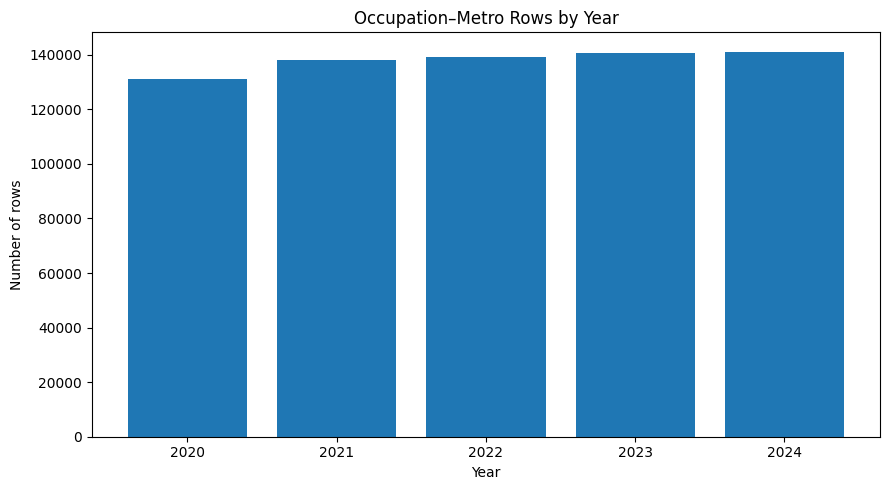

In [48]:
coverage_plot_pd = (
    df_all
    .group_by("year")
    .agg(pl.len().alias("n_rows"))
    .sort("year")
    .to_pandas()
)

plt.figure(figsize=(9, 5))
plt.bar(coverage_plot_pd["year"].astype(str), coverage_plot_pd["n_rows"])
plt.title("Occupation–Metro Rows by Year")
plt.xlabel("Year")
plt.ylabel("Number of rows")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_rows_by_year.png", dpi=150)
plt.show()

### Interpretation: row coverage by year

The row-count chart shows that the dataset has consistently strong coverage from 2020 through 2024. The number of occupation-metro rows increases from about **131,000 in 2020** to about **141,000 in 2024**.

This means we have enough data to support:

- year-over-year trend analysis,
- lagged feature creation,
- time-based train/validation/test splits,
- short-term forecasting.

### 10.2 Annual Wage Distribution

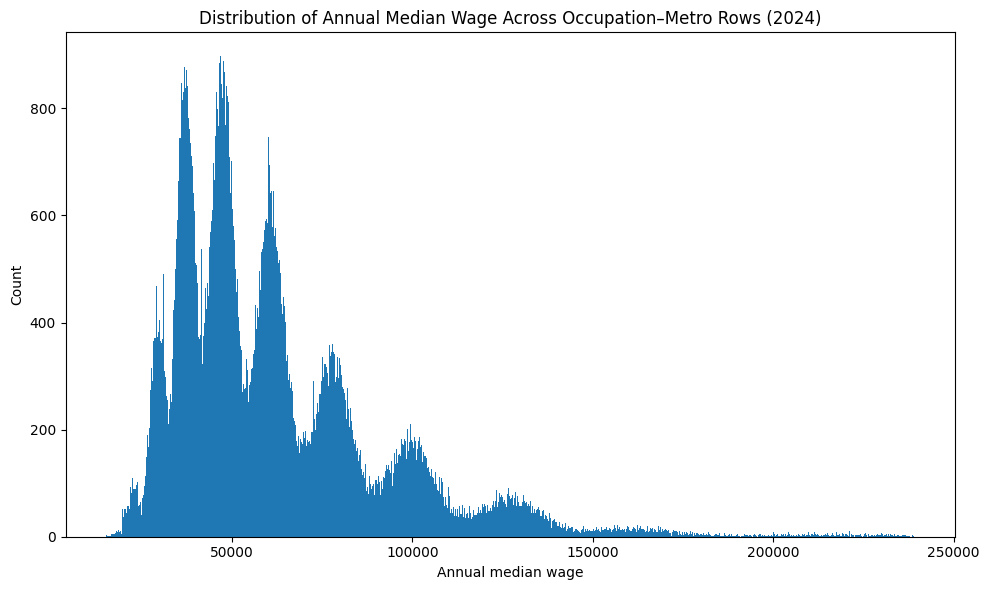

In [49]:
plot_df = eda_pd.dropna(subset=[wage_col]).copy()

plt.figure(figsize=(10, 6))
plt.hist(plot_df[wage_col], bins=1000)
plt.title(f"Distribution of Annual Median Wage Across Occupation–Metro Rows ({EDA_YEAR})")
plt.xlabel("Annual median wage")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_wage_distribution.png", dpi=150)
plt.show()

### Interpretation: annual wage distribution

The annual median wage distribution is strongly right-skewed. Most occupation-metro rows fall in the lower-to-middle wage range, while a smaller number of high-wage occupation-metro pairs extend far into the right tail.

This tells us that wages differ substantially across occupations and metros. It also reinforces why we should not evaluate a city’s affordability in general terms only. A metro that is affordable for a software developer may be extremely unaffordable for a cashier, retail worker, or home health aide.

The multi-peaked shape likely reflects different broad occupation groups: lower-wage service jobs, middle-income technical or administrative roles, and high-wage professional or medical occupations.

### 10.3 BEA RPP Distribution Across Metros

,cbsa_code,bls_msa_name,rpp_all_items,rpp_services_housing,annual_rent
107,41860,"San Francisco-Oakland-Fremont, CA",115.613,194.718,29688
64,33100,"Miami-Fort Lauderdale-West Palm Beach, FL",114.155,155.551,22428
131,31080,"Los Angeles-Long Beach-Anaheim, CA",113.566,170.433,24756
117,35620,"New York-Newark-Jersey City, NY-NJ",112.563,148.616,21960
54,34900,"Napa, CA",112.554,197.440,26844
186,41740,"San Diego-Chula Vista-Carlsbad, CA",111.887,179.267,26952
321,42660,"Seattle-Tacoma-Bellevue, WA",111.133,151.314,24000
268,46520,"Urban Honolulu, HI",110.961,135.538,24996
119,37100,"Oxnard-Thousand Oaks-Ventura, CA",110.534,171.096,27804
15,41940,"San Jose-Sunnyvale-Santa Clara, CA",110.423,211.901,34080


,cbsa_code,bls_msa_name,rpp_all_items,rpp_services_housing,annual_rent
74,33740,"Monroe, LA",83.597,42.815,11172
222,20580,"Eagle Pass, TX",83.805,53.681,10308
124,20020,"Dothan, AL",83.833,46.872,10920
346,45500,"Texarkana, TX-AR",84.012,49.885,11400
269,21420,"Enid, OK",84.269,51.389,11028
211,25220,"Hammond, LA",84.460,48.160,12036
55,43340,"Shreveport-Bossier City, LA",84.766,52.286,12168
204,22520,"Florence-Muscle Shoals, AL",84.817,47.677,10236
174,26380,"Houma-Bayou Cane-Thibodaux, LA",85.103,51.311,12168
31,48680,"Wildwood-The Villages, FL",85.424,51.733,15228


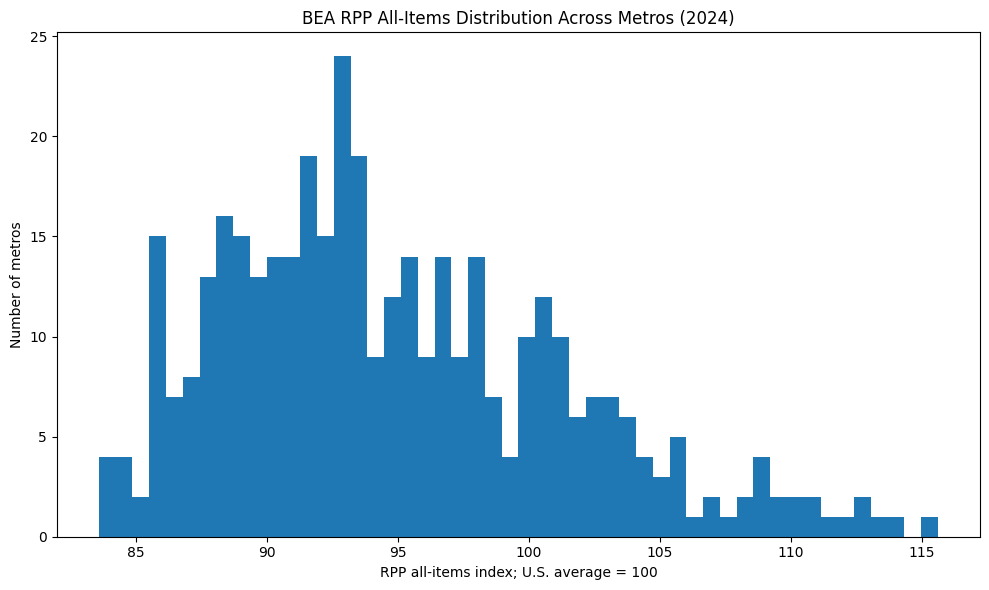

In [50]:
rpp_metro_pd = (
    eda_with_rpp
    .select([
        "cbsa_code",
        "bls_msa_name",
        "rpp_all_items",
        "rpp_services_housing",
        "annual_rent",
    ])
    .unique(subset=["cbsa_code"])
    .to_pandas()
)

display(rpp_metro_pd.sort_values("rpp_all_items", ascending=False).head(10))
display(rpp_metro_pd.sort_values("rpp_all_items").head(10))

plt.figure(figsize=(10, 6))
plt.hist(rpp_metro_pd["rpp_all_items"].dropna(), bins=50)
plt.title(f"BEA RPP All-Items Distribution Across Metros ({EDA_YEAR})")
plt.xlabel("RPP all-items index; U.S. average = 100")
plt.ylabel("Number of metros")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_rpp_all_items_distribution.png", dpi=150)
plt.show()

### Interpretation: BEA RPP distribution

The BEA RPP distribution shows that most metros are clustered near or below the national average price level of 100, while a smaller group of high-cost metros sits above 105.

This confirms that cost-of-living differences across metros are large enough to matter. A nominal wage comparison alone can be misleading because the same salary buys different amounts in different metros.

This is why the notebook creates RPP-adjusted wage and RPP-adjusted income-after-rent metrics. Those measures are closer to the real decision a person faces when comparing cities.

### 10.4 ACS Annual Rent vs. BEA Housing RPP

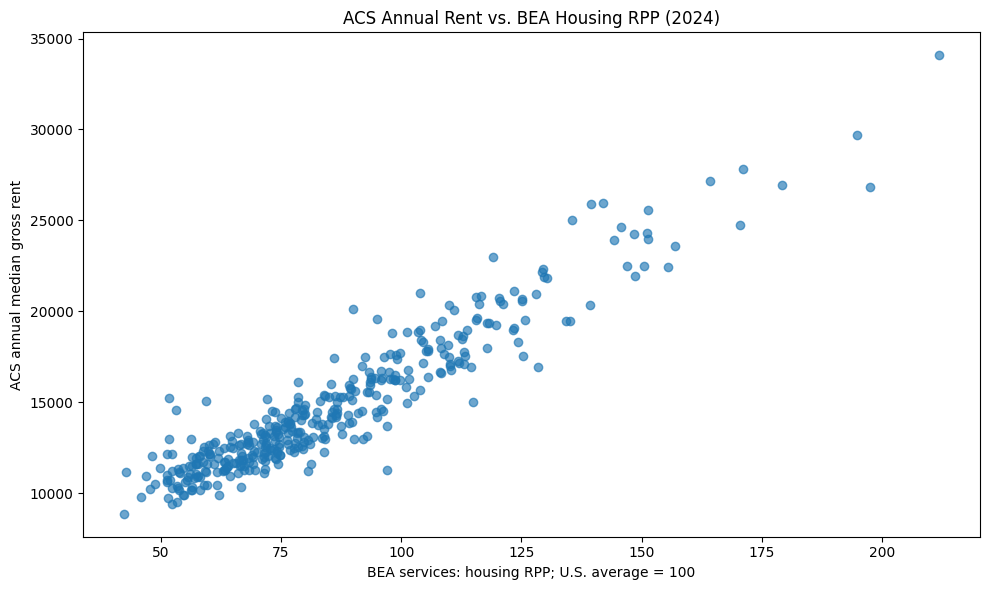

In [51]:
plot_df = rpp_metro_pd.dropna(subset=["annual_rent", "rpp_services_housing"]).copy()

plt.figure(figsize=(10, 6))
plt.scatter(plot_df["rpp_services_housing"], plot_df["annual_rent"], alpha=0.65)
plt.title(f"ACS Annual Rent vs. BEA Housing RPP ({EDA_YEAR})")
plt.xlabel("BEA services: housing RPP; U.S. average = 100")
plt.ylabel("ACS annual median gross rent")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_acs_rent_vs_bea_housing_rpp.png", dpi=150)
plt.show()

### Interpretation: ACS rent vs. BEA housing RPP

The scatterplot shows a strong positive relationship between ACS annual rent and BEA housing RPP. Metros with higher BEA housing price levels also tend to have higher observed rents.

This is a useful validation check. It shows that the BEA RPP housing measure is consistent with the ACS rent data, even though the two come from different sources.

The relationship is not perfect, which is also important. ACS rent and BEA RPP are related but not identical, so including both gives a richer view of local affordability.

### 10.5 Annual Rent vs. Annual Wage

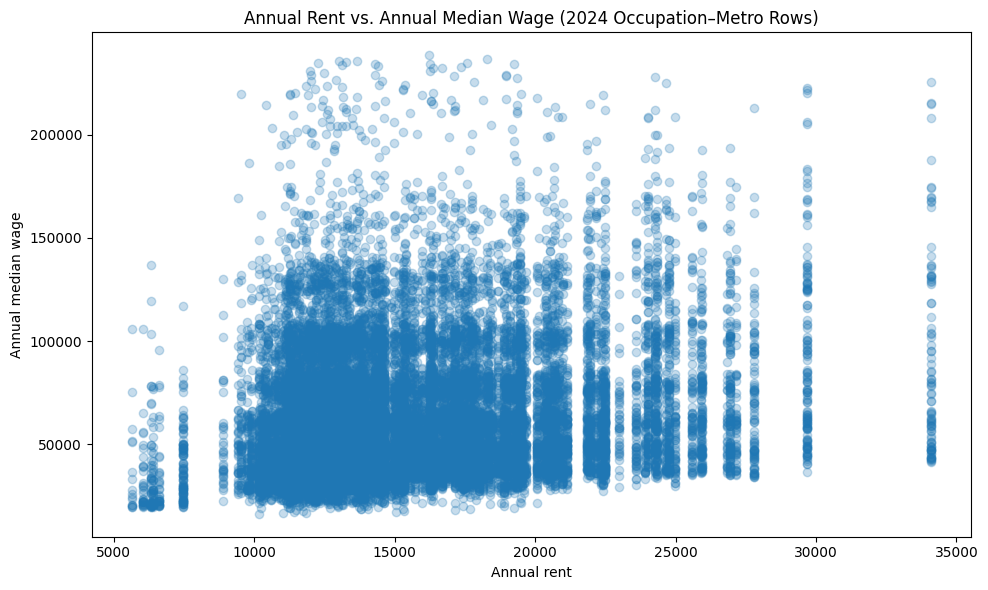

In [52]:
plot_df = eda_pd.dropna(subset=["annual_rent", wage_col]).copy()

if len(plot_df) > 25000:
    plot_df = plot_df.sample(25000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(plot_df["annual_rent"], plot_df[wage_col], alpha=0.25)
plt.title(f"Annual Rent vs. Annual Median Wage ({EDA_YEAR} Occupation–Metro Rows)")
plt.xlabel("Annual rent")
plt.ylabel("Annual median wage")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_rent_vs_wage_scatter.png", dpi=150)
plt.show()

### Interpretation: annual rent vs. annual median wage

This plot shows the core reason the project needs an occupation-metro dataset. Annual rent is measured at the metro level, so all occupations in the same metro share the same rent value. That creates vertical bands in the scatterplot.

Within each metro, wages vary widely by occupation. The same rent level can be manageable for a high-wage occupation and extremely burdensome for a low-wage occupation.

This supports the main dashboard design choice: users should select an occupation first, and then compare metros for that occupation.

### 10.6 Selected Occupation for Metro-Level Comparison

In [53]:
candidate_keywords = [
    "software developers",
    "registered nurses",
    "accountants",
    "data scientists",
    "financial analysts",
]

selected_occ = None
all_occ_titles = eda.select("occ_title").drop_nulls().unique().to_series().to_list()

for keyword in candidate_keywords:
    matches = [title for title in all_occ_titles if keyword in str(title).lower()]
    if matches:
        selected_occ = matches[0]
        break

if selected_occ is None:
    selected_occ = (
        eda
        .filter(pl.col("tot_emp").is_not_null())
        .group_by("occ_title")
        .agg(pl.sum("tot_emp").alias("total_emp"))
        .sort("total_emp", descending=True)
        .select("occ_title")
        .item()
    )

print("Selected occupation for metro-level comparison:")
print(selected_occ)

Selected occupation for metro-level comparison:
Software Developers


For the detailed metro-level EDA, the notebook uses **Software Developers** as the selected occupation.

This is a useful case study because software development has high wages, strong metro variation, and meaningful differences in local labor-market concentration. It also makes the tradeoff between high-cost tech hubs and lower-cost alternative metros very visible.

The same analysis framework can later be applied to any occupation in the dashboard.

### 10.7 Top Metros for Selected Occupation by Rent Burden

,bls_msa_name,wage_annual_median,annual_rent,rent_to_median_wage_ratio,tot_emp,loc_quotient
0,"Aguadilla, PR",77370.0,6336,0.081892,120.0,0.23
1,"Hickory-Lenoir-Morganton, NC",121590.0,10428,0.085764,360.0,0.21
2,"Binghamton, NY",129600.0,11268,0.086944,1130.0,1.10
3,"Kingsport-Bristol, TN-VA",114540.0,10188,0.088947,440.0,0.35
4,"Johnstown, PA",97160.0,8868,0.091272,110.0,0.22
5,"Youngstown-Warren, OH",101870.0,9540,0.093649,270.0,0.16
6,"Ames, IA",127040.0,12000,0.094458,440.0,0.73
7,"Decatur, AL",105830.0,10164,0.096041,140.0,0.23
8,"Yuma, AZ",123840.0,11916,0.096221,200.0,0.26
9,"Winston-Salem, NC",125140.0,12192,0.097427,1270.0,0.43


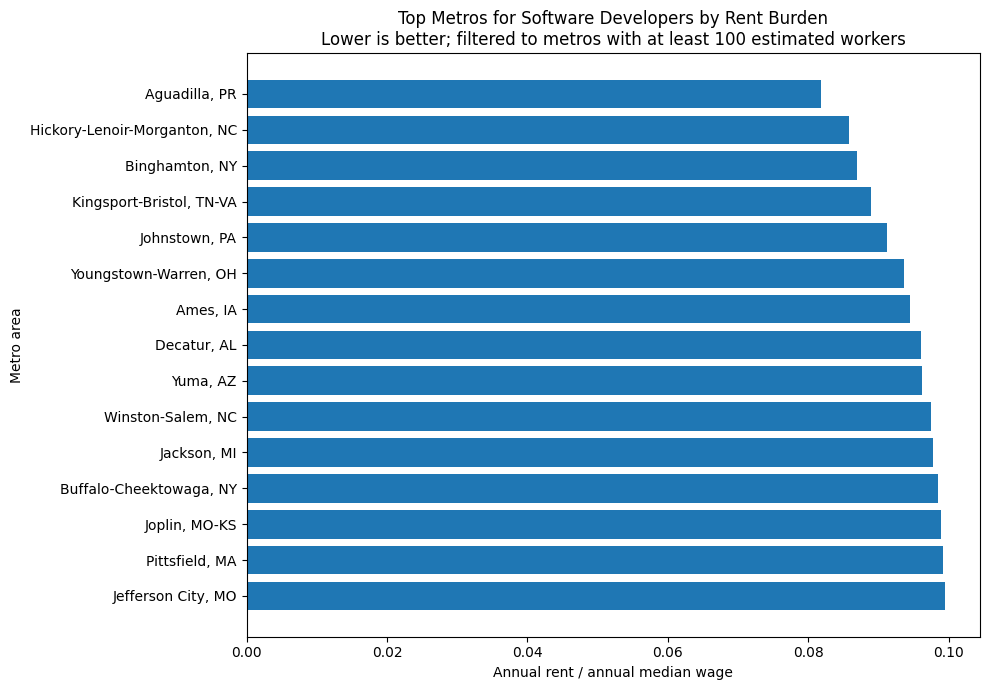

In [54]:
MIN_OCC_EMP = 100

selected_occ_base = (
    eda
    .filter(pl.col("occ_title") == selected_occ)
    .filter(pl.col(ratio_col).is_not_null())
)

selected_occ_filtered = selected_occ_base.filter(
    pl.col("tot_emp").is_not_null() & (pl.col("tot_emp") >= MIN_OCC_EMP)
)

if selected_occ_filtered.height >= 15:
    occ_rank_source = selected_occ_filtered
    rank_note = f"filtered to metros with at least {MIN_OCC_EMP:,} estimated workers"
else:
    occ_rank_source = selected_occ_base
    rank_note = "unfiltered because too few metros passed the employment filter"

occ_df = (
    occ_rank_source
    .sort(ratio_col)
    .head(15)
    .select([
        "bls_msa_name",
        wage_col,
        "annual_rent",
        ratio_col,
        "tot_emp",
        "loc_quotient",
    ])
    .to_pandas()
)

display(occ_df)

plt.figure(figsize=(10, 7))
plt.barh(occ_df["bls_msa_name"], occ_df[ratio_col])
plt.title(f"Top Metros for {selected_occ} by Rent Burden\nLower is better; {rank_note}")
plt.xlabel("Annual rent / annual median wage")
plt.ylabel("Metro area")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "06_selected_occupation_top_metros_rent_burden.png", dpi=150)
plt.show()

### Interpretation: top metros by rent burden

Ranking software-developer metros by rent burden highlights places where typical annual rent is small relative to the occupation’s annual median wage.

The lowest rent-burden metros include places like Aguadilla, Hickory-Lenoir-Morganton, Binghamton, Kingsport-Bristol, Johnstown, Ames, Winston-Salem, Buffalo, and Joplin. Many of these are smaller or lower-cost metros that would not necessarily appear at the top of a simple nominal-wage ranking.

This result shows that affordability can make some less obvious metros look very attractive. However, rent burden alone is not enough. Some affordable metros have low employment counts or low location quotients for software developers, so the dashboard should also show labor-market strength.

### 10.8 Top Metros for Selected Occupation by RPP-Adjusted Income After Rent

,bls_msa_name,wage_annual_median,real_wage_annual_median,annual_rent,rpp_all_items,real_income_after_rent_median,tot_emp,loc_quotient
0,"San Jose-Sunnyvale-Santa Clara, CA",208270.0,188611.068346,34080,110.423,157747.932949,90280.0,7.42
1,"Seattle-Tacoma-Bellevue, WA",169340.0,152375.981932,24000,111.133,130780.236293,72730.0,3.25
2,"Ames, IA",127040.0,143014.747270,12000,88.830,129505.797591,440.0,0.73
3,"Boulder, CO",159670.0,151774.681090,23592,105.202,129349.251915,7790.0,3.71
4,"Wildwood-The Villages, FL",124620.0,145884.060686,15228,85.424,128057.688706,130.0,0.31
5,"Binghamton, NY",129600.0,139560.427727,11268,92.863,127426.423872,1130.0,1.10
6,"Rochester, MN",130480.0,143667.213530,15312,90.821,126807.676639,1630.0,1.25
7,"Bridgeport-Stamford-Danbury, CT",157540.0,147421.021111,22500,106.864,126366.222488,3800.0,0.88
8,"Santa Maria-Santa Barbara, CA",163020.0,149837.313186,25572,108.798,126333.204654,2030.0,0.94
9,"Pittsfield, MA",132760.0,139591.613568,13164,95.106,125750.215549,310.0,0.51


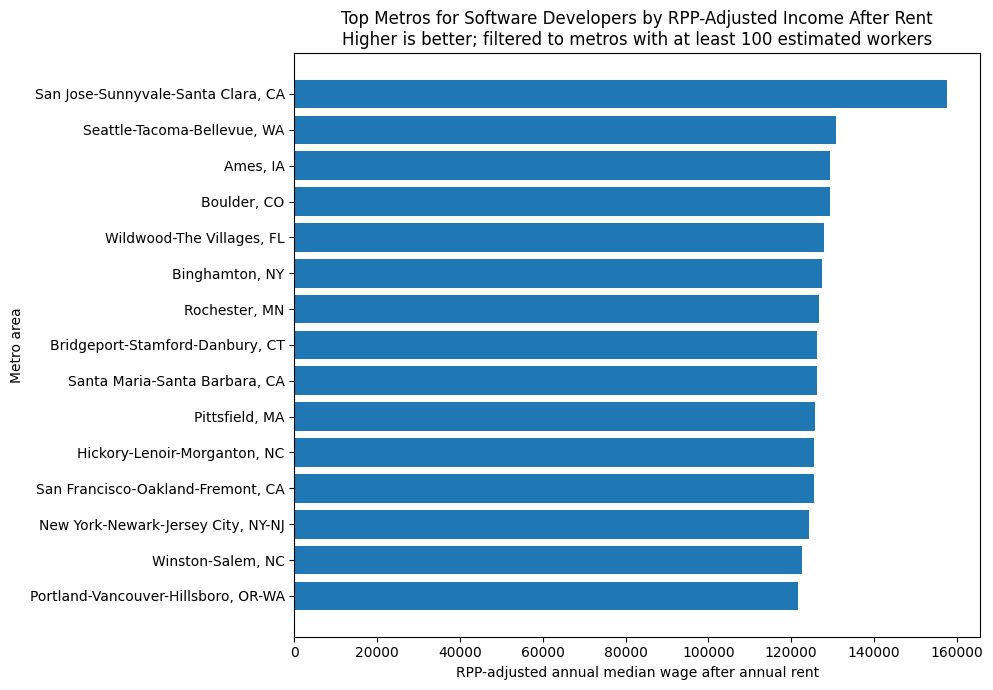

In [55]:
selected_occ_real = (
    eda_with_rpp
    .filter(pl.col("occ_title") == selected_occ)
    .filter(pl.col(real_after_rent_col).is_not_null())
)

selected_occ_real_filtered = selected_occ_real.filter(
    pl.col("tot_emp").is_not_null() & (pl.col("tot_emp") >= MIN_OCC_EMP)
)

if selected_occ_real_filtered.height >= 15:
    real_rank_source = selected_occ_real_filtered
    real_rank_note = f"filtered to metros with at least {MIN_OCC_EMP:,} estimated workers"
else:
    real_rank_source = selected_occ_real
    real_rank_note = "unfiltered because too few metros passed the employment filter"

real_occ_df = (
    real_rank_source
    .sort(real_after_rent_col, descending=True)
    .head(15)
    .select([
        "bls_msa_name",
        wage_col,
        real_wage_col,
        "annual_rent",
        "rpp_all_items",
        real_after_rent_col,
        "tot_emp",
        "loc_quotient",
    ])
    .to_pandas()
)

display(real_occ_df)

plt.figure(figsize=(10, 7))
plt.barh(real_occ_df["bls_msa_name"], real_occ_df[real_after_rent_col])
plt.title(
    f"Top Metros for {selected_occ} by RPP-Adjusted Income After Rent\n"
    f"Higher is better; {real_rank_note}"
)
plt.xlabel("RPP-adjusted annual median wage after annual rent")
plt.ylabel("Metro area")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "07_selected_occupation_top_metros_real_income_after_rent.png", dpi=150)
plt.show()

### Interpretation: top metros by RPP-adjusted income after rent

This ranking uses a more complete metric: annual median wage minus annual rent, adjusted by BEA RPP. In other words, it estimates how much cost-adjusted purchasing power remains after paying typical annual rent.

The ranking tells a more nuanced story than rent burden alone. San Jose and Seattle rank very highly because their software-developer wage premiums are large enough to offset high rents and high price levels. At the same time, lower-cost metros like Ames, Binghamton, Hickory-Lenoir-Morganton, Winston-Salem, and Rochester also perform very well because wages stretch further there.

The main takeaway is that expensive metros are not automatically bad, and cheap metros are not automatically best. The best city depends on the balance between wages, rent, cost of living, and labor-market strength.

### 10.9 Location Quotient vs. Real Wage for Selected Occupation

,bls_msa_name,loc_quotient,wage_annual_median,real_wage_annual_median,tot_emp,rent_to_median_wage_ratio,rpp_all_items
0,"Abilene, TX",0.33,102870.0,113839.582134,260.0,0.133100,90.364
1,"Akron, OH",0.67,101110.0,108289.600514,2290.0,0.122599,93.370
2,"Albany, GA",0.28,101670.0,115970.297369,180.0,0.112127,87.669
3,"Albany, OR",0.21,120800.0,118315.377081,100.0,0.131126,102.100
4,"Albany-Schenectady-Troy, NY",0.62,115970.0,116475.503686,2970.0,0.132448,99.566


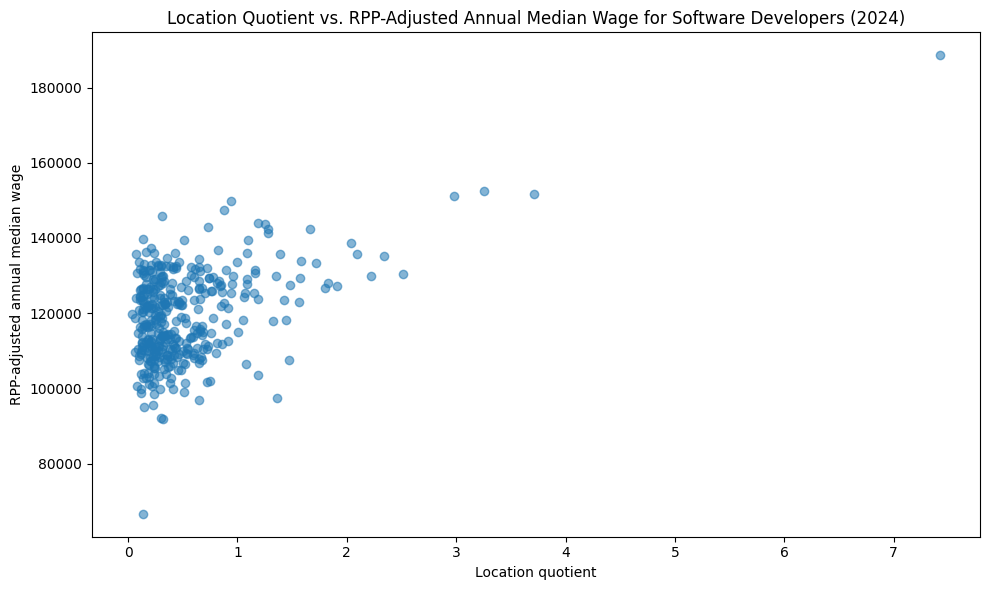

In [56]:
lq_df = (
    eda_with_rpp
    .filter(pl.col("occ_title") == selected_occ)
    .filter(pl.col("loc_quotient").is_not_null())
    .filter(pl.col(real_wage_col).is_not_null())
    .select([
        "bls_msa_name",
        "loc_quotient",
        wage_col,
        real_wage_col,
        "tot_emp",
        ratio_col,
        "rpp_all_items",
    ])
    .to_pandas()
)

display(lq_df.head())

plt.figure(figsize=(10, 6))
plt.scatter(lq_df["loc_quotient"], lq_df[real_wage_col], alpha=0.55)
plt.title(f"Location Quotient vs. RPP-Adjusted Annual Median Wage for {selected_occ} ({EDA_YEAR})")
plt.xlabel("Location quotient")
plt.ylabel("RPP-adjusted annual median wage")
plt.tight_layout()
plt.savefig(FIG_DIR / "08_selected_occupation_lq_vs_real_wage.png", dpi=150)
plt.show()

### Interpretation: location quotient vs. RPP-adjusted wage

This plot compares two different dimensions of career-city fit:

- RPP-adjusted wage, which measures purchasing-power-adjusted pay.
- Location quotient, which measures how concentrated the occupation is in the local labor market.

For software developers, most metros have location quotients below 1, meaning software development is less concentrated there than nationally. A few metros stand out with both high location quotient and high adjusted wages.

San Jose is the clearest example of a high-concentration, high-wage tech market. However, the plot also shows that a metro does not need to be a major tech hub to offer solid cost-adjusted wages.

This supports the dashboard idea that users should be able to weigh both affordability and job-market depth.

### 10.10 Nominal Wage Rank vs. RPP-Adjusted Wage Rank

Metros whose wage ranking improves most after RPP adjustment:


,bls_msa_name,wage_annual_median,real_wage_annual_median,annual_rent,rpp_all_items,tot_emp,loc_quotient,nominal_wage_rank,real_wage_rank,rank_change_after_rpp_adjustment
336,"Texarkana, TX-AR",109840.0,130743.227158,11400,84.012,90.0,0.14,193.0,63.0,130.0
175,"Kingsport-Bristol, TN-VA",114540.0,132497.368330,10188,86.447,440.0,0.35,167.0,42.0,125.0
167,"Joplin, MO-KS",112620.0,131384.306680,11136,85.718,130.0,0.14,179.0,56.0,123.0
316,"Shreveport-Bossier City, LA",109870.0,129615.647783,12168,84.766,280.0,0.16,192.0,75.0,117.0
94,"Dothan, AL",100810.0,120250.975153,10920,83.833,90.0,0.14,296.0,181.0,115.0
228,"Monroe, LA",103850.0,124226.945943,11172,83.597,100.0,0.11,243.0,134.0,109.0
350,"Victoria, TX",120030.0,133605.672369,13812,89.839,40.0,0.10,139.0,33.0,106.0
145,"Hickory-Lenoir-Morganton, NC",121590.0,137411.567932,10428,88.486,360.0,0.21,122.0,18.0,104.0
139,"Hammond, LA",101520.0,120198.910727,12036,84.460,70.0,0.13,285.0,182.0,103.0
103,"El Paso, TX",121160.0,134753.981671,12948,89.912,1300.0,0.36,130.0,28.0,102.0


Metros whose wage ranking falls most after RPP adjustment:


,bls_msa_name,wage_annual_median,real_wage_annual_median,annual_rent,rpp_all_items,tot_emp,loc_quotient,nominal_wage_rank,real_wage_rank,rank_change_after_rpp_adjustment
218,"Miami-Fort Lauderdale-West Palm Beach, FL",129840.0,113740.090228,22428,114.155,17710.0,0.59,51.0,240.0,-189.0
346,"Urban Honolulu, HI",118630.0,106911.437352,24996,110.961,1630.0,0.34,147.0,331.0,-184.0
237,"Napa, CA",131050.0,116433.001048,26844,112.554,120.0,0.15,39.0,213.0,-174.0
44,"Bozeman, MT",107590.0,104955.614086,20328,102.510,370.0,0.48,204.0,345.0,-141.0
305,"San Luis Obispo-Paso Robles, CA",132010.0,121560.646801,23904,108.596,480.0,0.37,33.0,169.0,-136.0
177,"Kiryas Joel-Poughkeepsie-Newburgh, NY",134010.0,122470.801119,19656,109.422,960.0,0.34,26.0,158.0,-132.0
156,"Ithaca, NY",105000.0,101628.967159,16932,103.317,370.0,0.72,227.0,359.0,-132.0
173,"Kenosha, WI",106070.0,104897.248759,14628,101.118,360.0,0.46,220.0,346.0,-126.0
296,"Salinas, CA",134300.0,123163.551659,24660,109.042,280.0,0.14,24.0,148.0,-124.0
248,"Ogden, UT",106770.0,106398.668646,18000,100.349,3130.0,1.08,213.0,337.0,-124.0


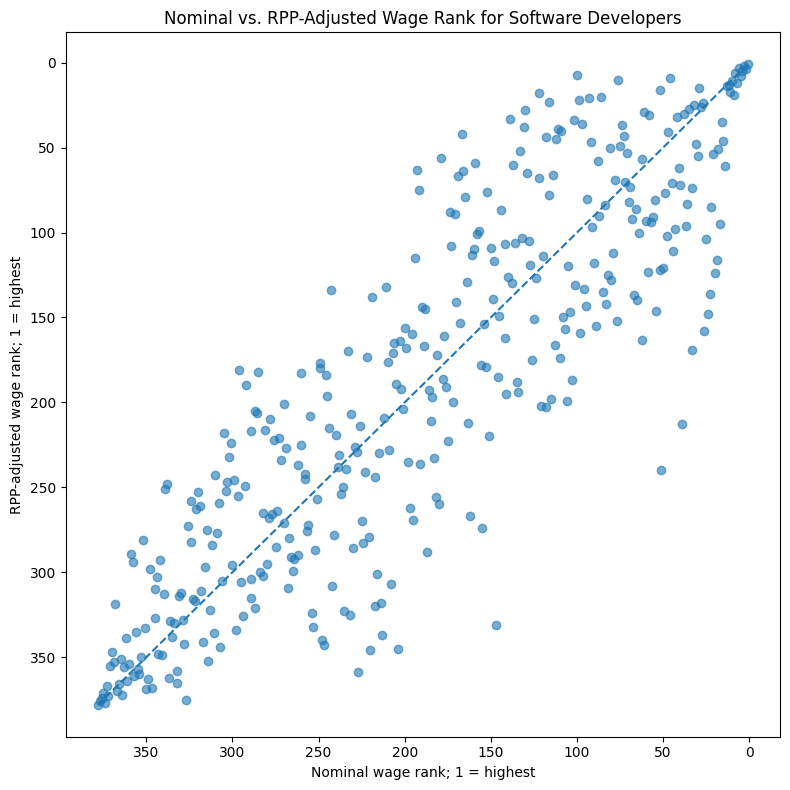

In [57]:
rank_shift_df = (
    eda_with_rpp
    .filter(pl.col("occ_title") == selected_occ)
    .filter(pl.col(wage_col).is_not_null())
    .filter(pl.col(real_wage_col).is_not_null())
    .select([
        "bls_msa_name",
        wage_col,
        real_wage_col,
        "annual_rent",
        "rpp_all_items",
        "tot_emp",
        "loc_quotient",
    ])
    .to_pandas()
)

rank_shift_df["nominal_wage_rank"] = rank_shift_df[wage_col].rank(ascending=False, method="min")
rank_shift_df["real_wage_rank"] = rank_shift_df[real_wage_col].rank(ascending=False, method="min")
rank_shift_df["rank_change_after_rpp_adjustment"] = (
    rank_shift_df["nominal_wage_rank"] - rank_shift_df["real_wage_rank"]
)

print("Metros whose wage ranking improves most after RPP adjustment:")
display(
    rank_shift_df
    .sort_values("rank_change_after_rpp_adjustment", ascending=False)
    .head(10)
)

print("Metros whose wage ranking falls most after RPP adjustment:")
display(
    rank_shift_df
    .sort_values("rank_change_after_rpp_adjustment")
    .head(10)
)

plot_df = rank_shift_df.dropna(subset=["nominal_wage_rank", "real_wage_rank"]).copy()

plt.figure(figsize=(8, 8))
plt.scatter(plot_df["nominal_wage_rank"], plot_df["real_wage_rank"], alpha=0.6)
plt.plot(
    [plot_df["nominal_wage_rank"].min(), plot_df["nominal_wage_rank"].max()],
    [plot_df["nominal_wage_rank"].min(), plot_df["nominal_wage_rank"].max()],
    linestyle="--",
)
plt.title(f"Nominal vs. RPP-Adjusted Wage Rank for {selected_occ}")
plt.xlabel("Nominal wage rank; 1 = highest")
plt.ylabel("RPP-adjusted wage rank; 1 = highest")
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "09_selected_occupation_nominal_vs_real_wage_rank.png", dpi=150)
plt.show()

### Interpretation: nominal wage rank vs. RPP-adjusted wage rank

This is one of the most important EDA results. The plot shows that metro rankings can change substantially after adjusting wages for BEA regional price levels.

Some metros improve dramatically after RPP adjustment. Examples include Texarkana, Kingsport-Bristol, Joplin, Shreveport-Bossier City, Dothan, Hickory-Lenoir-Morganton, and El Paso. These metros may not have the highest nominal software-developer wages, but their lower price levels make those wages go further. These lie on the left hand side of the diagonal line.

Other metros fall sharply after RPP adjustment. Examples include Miami, Urban Honolulu, Napa, Bozeman, San Luis Obispo, Ithaca, Salinas, and parts of California and New York. These places may look stronger under nominal wages than they do after accounting for local prices. These lie on the right hand side of the diagonal line.

This confirms the central value of the project: nominal wages alone do not tell the full career-city story.

### 10.11 Rent-Burden Distribution for High-Employment Occupations

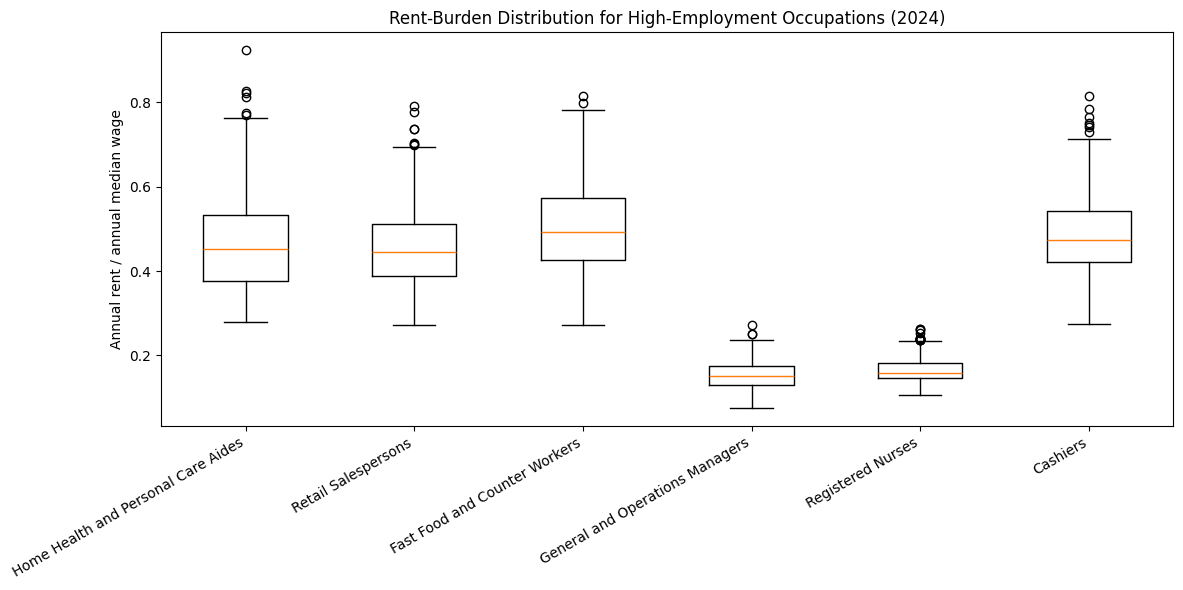

In [58]:
top_occ = (
    eda
    .filter(pl.col("tot_emp").is_not_null())
    .group_by("occ_title")
    .agg(pl.sum("tot_emp").alias("total_emp"))
    .sort("total_emp", descending=True)
    .head(6)
    .select("occ_title")
    .to_series()
    .to_list()
)

box_df = (
    eda
    .filter(pl.col("occ_title").is_in(top_occ))
    .filter(pl.col(ratio_col).is_not_null())
    .select(["occ_title", ratio_col])
    .to_pandas()
)

grouped_values = [
    box_df.loc[box_df["occ_title"] == occ, ratio_col].values
    for occ in top_occ
]

plt.figure(figsize=(12, 6))
plt.boxplot(grouped_values, tick_labels=top_occ, vert=True)
plt.title(f"Rent-Burden Distribution for High-Employment Occupations ({EDA_YEAR})")
plt.ylabel("Annual rent / annual median wage")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "10_rent_burden_boxplot_top_occupations.png", dpi=150)
plt.show()

### Interpretation: rent burden across high-employment occupations

The rent-burden boxplot shows that affordability differs sharply by occupation.

High-employment lower-wage occupations such as home health aides, retail salespersons, fast food workers, and cashiers have much higher rent burdens. In many metros, annual rent takes up a very large share of annual median wage for these occupations.

By contrast, registered nurses and general and operations managers have much lower rent burdens because their wages are higher relative to metro rent levels.

This shows very clearly why the dashboard should be occupation-specific. A city can only labeled “affordable” or “unaffordable” without knowledge of career.

### 10.12 Selected Occupation Rent-Burden and Real-Income Trends, 2020-2024

,year,bls_msa_name,rent_to_median_wage_ratio,real_income_after_rent_median
0,2021,"Dallas-Fort Worth-Arlington, TX",0.126148,101065.753530
1,2022,"Dallas-Fort Worth-Arlington, TX",0.137475,102581.905388
2,2023,"Dallas-Fort Worth-Arlington, TX",0.139841,108675.968387
3,2024,"Dallas-Fort Worth-Arlington, TX",0.147296,108761.276554
4,2024,"New York-Newark-Jersey City, NY-NJ",0.135581,124383.678473
5,2024,"San Francisco-Oakland-Fremont, CA",0.169733,125610.441732
6,2021,"San Jose-Sunnyvale-Santa Clara, CA",0.182585,120863.348027
7,2022,"San Jose-Sunnyvale-Santa Clara, CA",0.167568,139464.439066
8,2023,"San Jose-Sunnyvale-Santa Clara, CA",0.168398,146447.430103
9,2024,"San Jose-Sunnyvale-Santa Clara, CA",0.163634,157747.932949


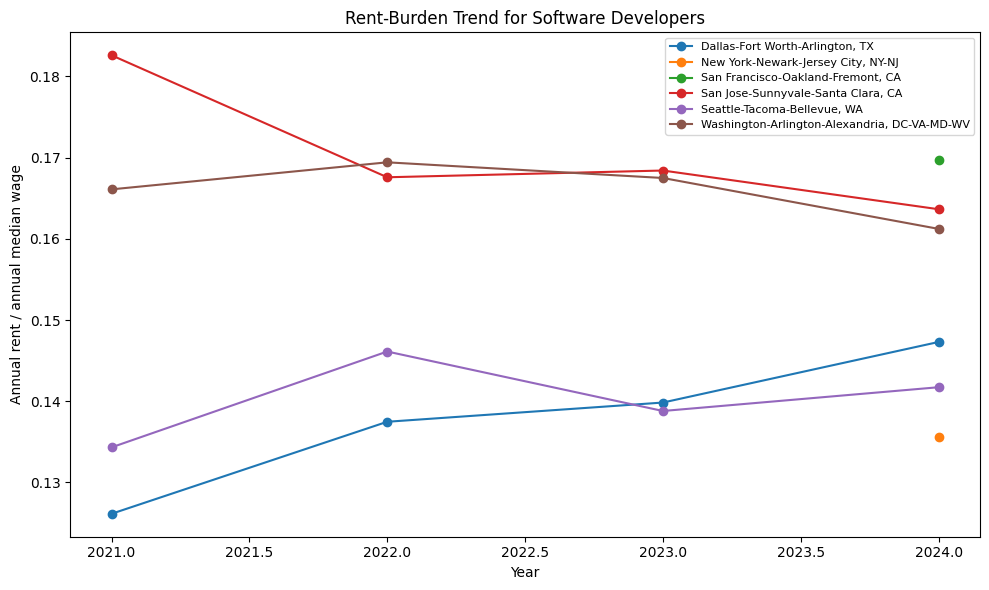

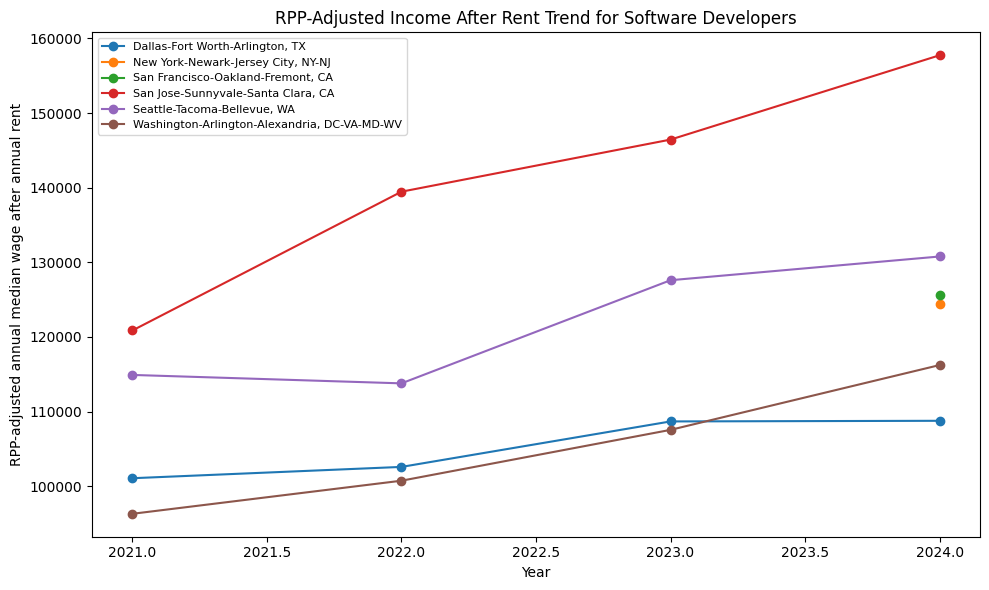

In [59]:
trend_base = (
    df_all
    .filter(pl.col("occ_title") == selected_occ)
    .filter(pl.col(ratio_col).is_not_null())
    .filter(pl.col(real_after_rent_col).is_not_null())
    .filter(pl.col("tot_emp").is_not_null())
)

top_trend_metros = (
    trend_base
    .filter(pl.col("year") == EDA_YEAR)
    .sort("tot_emp", descending=True)
    .head(6)
    .select("bls_msa_name")
    .to_series()
    .to_list()
)

trend_pd = (
    trend_base
    .filter(pl.col("bls_msa_name").is_in(top_trend_metros))
    .select(["year", "bls_msa_name", ratio_col, real_after_rent_col])
    .sort(["bls_msa_name", "year"])
    .to_pandas()
)

display(trend_pd.head(20))

plt.figure(figsize=(10, 6))

for metro_name, group in trend_pd.groupby("bls_msa_name"):
    plt.plot(group["year"], group[ratio_col], marker="o", label=metro_name)

plt.title(f"Rent-Burden Trend for {selected_occ}")
plt.xlabel("Year")
plt.ylabel("Annual rent / annual median wage")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "11_selected_occupation_rent_burden_trend.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 6))

for metro_name, group in trend_pd.groupby("bls_msa_name"):
    plt.plot(group["year"], group[real_after_rent_col], marker="o", label=metro_name)

plt.title(f"RPP-Adjusted Income After Rent Trend for {selected_occ}")
plt.xlabel("Year")
plt.ylabel("RPP-adjusted annual median wage after annual rent")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "12_selected_occupation_real_income_after_rent_trend.png", dpi=150)
plt.show()

### Interpretation: selected occupation trends

The trend charts show how affordability changes over time for software developers in several major metros.

The rent-burden trend shows that some metros became less affordable over time, while others improved or stayed relatively stable. For example, Dallas-Fort Worth shows rising rent burden from 2021 to 2024, while San Jose’s rent burden improves slightly by 2024 because software-developer wages increased enough to offset rent pressure.

The RPP-adjusted income-after-rent trend gives another view. San Jose, Seattle, Dallas, and Washington DC all show increases in real income after rent over time. This suggests that, for high-wage occupations, expensive metros can still generate strong after-rent purchasing power.

Together, the two trend charts show why the dashboard should not rely on a single metric. Rent burden and real income after rent capture related but different parts of the decision.

## 11. SQL-Based Analysis with DuckDB

This section uses SQL to query the final processed occupation–metro dataset. The goal is not to replace the Polars/Pandas pipeline, but to explicitly demonstrate SQL-style analysis on the final relational table.

These queries support the dashboard and final presentation by checking:

1. yearly data coverage,
2. top metros for a selected occupation by RPP-adjusted income after rent,
3. how city rankings change after BEA RPP cost-of-living adjustment.

In [60]:
import duckdb

sql_df = read_final_dataset().to_pandas()

sql_con = duckdb.connect(database=":memory:")
sql_con.register("career_city", sql_df)

selected_occ_for_sql = selected_occ if "selected_occ" in globals() else (
    sql_df["occ_title"].dropna().value_counts().index[0]
)

print(f"Selected occupation for SQL examples: {selected_occ_for_sql}")

sql_coverage = sql_con.execute(
    """
    SELECT
        year,
        COUNT(*) AS n_rows,
        COUNT(DISTINCT cbsa_code) AS n_metros,
        COUNT(DISTINCT occ_code) AS n_occupations,
        ROUND(AVG(CASE WHEN annual_rent IS NOT NULL THEN 1 ELSE 0 END) * 100, 2) AS pct_with_rent,
        ROUND(AVG(CASE WHEN rpp_all_items IS NOT NULL THEN 1 ELSE 0 END) * 100, 2) AS pct_with_bea_rpp,
        ROUND(AVG(CASE WHEN real_income_after_rent_median IS NOT NULL THEN 1 ELSE 0 END) * 100, 2) AS pct_with_real_income_after_rent
    FROM career_city
    GROUP BY year
    ORDER BY year
    """
).df()

display(sql_coverage)

sql_top_real_income = sql_con.execute(
    """
    SELECT
        bls_msa_name,
        occ_title,
        wage_annual_median,
        real_wage_annual_median,
        annual_rent,
        rpp_all_items,
        real_income_after_rent_median,
        rent_to_median_wage_ratio,
        tot_emp,
        loc_quotient
    FROM career_city
    WHERE year = ?
      AND occ_title = ?
      AND real_income_after_rent_median IS NOT NULL
      AND COALESCE(tot_emp, 0) >= 100
    ORDER BY real_income_after_rent_median DESC
    LIMIT 15
    """,
    [EDA_YEAR, selected_occ_for_sql],
).df()

print("Top metros by RPP-adjusted income after rent:")
display(sql_top_real_income)

sql_rank_shift = sql_con.execute(
    """
    WITH ranked AS (
        SELECT
            bls_msa_name,
            occ_title,
            wage_annual_median,
            real_wage_annual_median,
            annual_rent,
            rpp_all_items,
            tot_emp,
            loc_quotient,
            RANK() OVER (ORDER BY wage_annual_median DESC) AS nominal_wage_rank,
            RANK() OVER (ORDER BY real_wage_annual_median DESC) AS real_wage_rank
        FROM career_city
        WHERE year = ?
          AND occ_title = ?
          AND wage_annual_median IS NOT NULL
          AND real_wage_annual_median IS NOT NULL
    )
    SELECT
        *,
        nominal_wage_rank - real_wage_rank AS rank_change_after_rpp_adjustment
    FROM ranked
    ORDER BY rank_change_after_rpp_adjustment DESC
    LIMIT 15
    """,
    [EDA_YEAR, selected_occ_for_sql],
).df()

print("Metros whose wage rank improves most after RPP adjustment:")
display(sql_rank_shift)

sql_rank_fall = sql_con.execute(
    """
    WITH ranked AS (
        SELECT
            bls_msa_name,
            occ_title,
            wage_annual_median,
            real_wage_annual_median,
            annual_rent,
            rpp_all_items,
            tot_emp,
            loc_quotient,
            RANK() OVER (ORDER BY wage_annual_median DESC) AS nominal_wage_rank,
            RANK() OVER (ORDER BY real_wage_annual_median DESC) AS real_wage_rank
        FROM career_city
        WHERE year = ?
          AND occ_title = ?
          AND wage_annual_median IS NOT NULL
          AND real_wage_annual_median IS NOT NULL
    )
    SELECT
        *,
        nominal_wage_rank - real_wage_rank AS rank_change_after_rpp_adjustment
    FROM ranked
    ORDER BY rank_change_after_rpp_adjustment ASC
    LIMIT 15
    """,
    [EDA_YEAR, selected_occ_for_sql],
).df()

print("Metros whose wage rank falls most after RPP adjustment:")
display(sql_rank_fall)

sql_con.close()

Selected occupation for SQL examples: Software Developers


,year,n_rows,n_metros,n_occupations,pct_with_rent,pct_with_bea_rpp,pct_with_real_income_after_rent
0,2020,131010,396,785,93.72,90.88,88.51
1,2021,138116,396,826,93.77,90.87,89.36
2,2022,139124,396,828,93.86,90.93,89.55
3,2023,140518,396,826,92.75,90.89,89.45
4,2024,141164,393,823,100.00,99.03,97.38


Top metros by RPP-adjusted income after rent:


,bls_msa_name,occ_title,wage_annual_median,real_wage_annual_median,annual_rent,rpp_all_items,real_income_after_rent_median,rent_to_median_wage_ratio,tot_emp,loc_quotient
0,"San Jose-Sunnyvale-Santa Clara, CA",Software Developers,208270.0,188611.068346,34080.0,110.423,157747.932949,0.163634,90280.0,7.42
1,"Seattle-Tacoma-Bellevue, WA",Software Developers,169340.0,152375.981932,24000.0,111.133,130780.236293,0.141727,72730.0,3.25
2,"Ames, IA",Software Developers,127040.0,143014.747270,12000.0,88.830,129505.797591,0.094458,440.0,0.73
3,"Boulder, CO",Software Developers,159670.0,151774.681090,23592.0,105.202,129349.251915,0.147755,7790.0,3.71
4,"Wildwood-The Villages, FL",Software Developers,124620.0,145884.060686,15228.0,85.424,128057.688706,0.122195,130.0,0.31
5,"Binghamton, NY",Software Developers,129600.0,139560.427727,11268.0,92.863,127426.423872,0.086944,1130.0,1.10
6,"Rochester, MN",Software Developers,130480.0,143667.213530,15312.0,90.821,126807.676639,0.117351,1630.0,1.25
7,"Bridgeport-Stamford-Danbury, CT",Software Developers,157540.0,147421.021111,22500.0,106.864,126366.222488,0.142821,3800.0,0.88
8,"Santa Maria-Santa Barbara, CA",Software Developers,163020.0,149837.313186,25572.0,108.798,126333.204654,0.156864,2030.0,0.94
9,"Pittsfield, MA",Software Developers,132760.0,139591.613568,13164.0,95.106,125750.215549,0.099156,310.0,0.51


Metros whose wage rank improves most after RPP adjustment:


,bls_msa_name,occ_title,wage_annual_median,real_wage_annual_median,annual_rent,rpp_all_items,tot_emp,loc_quotient,nominal_wage_rank,real_wage_rank,rank_change_after_rpp_adjustment
0,"Texarkana, TX-AR",Software Developers,109840.0,130743.227158,11400.0,84.012,90.0,0.14,193,63,130
1,"Kingsport-Bristol, TN-VA",Software Developers,114540.0,132497.368330,10188.0,86.447,440.0,0.35,167,42,125
2,"Joplin, MO-KS",Software Developers,112620.0,131384.306680,11136.0,85.718,130.0,0.14,179,56,123
3,"Shreveport-Bossier City, LA",Software Developers,109870.0,129615.647783,12168.0,84.766,280.0,0.16,192,75,117
4,"Dothan, AL",Software Developers,100810.0,120250.975153,10920.0,83.833,90.0,0.14,296,181,115
5,"Monroe, LA",Software Developers,103850.0,124226.945943,11172.0,83.597,100.0,0.11,243,134,109
6,"Victoria, TX",Software Developers,120030.0,133605.672369,13812.0,89.839,40.0,0.10,139,33,106
7,"Hickory-Lenoir-Morganton, NC",Software Developers,121590.0,137411.567932,10428.0,88.486,360.0,0.21,122,18,104
8,"Hammond, LA",Software Developers,101520.0,120198.910727,12036.0,84.460,70.0,0.13,285,182,103
9,"Brunswick-St. Simons, GA",Software Developers,114670.0,130740.639394,12960.0,87.708,40.0,0.08,166,64,102


Metros whose wage rank falls most after RPP adjustment:


,bls_msa_name,occ_title,wage_annual_median,real_wage_annual_median,annual_rent,rpp_all_items,tot_emp,loc_quotient,nominal_wage_rank,real_wage_rank,rank_change_after_rpp_adjustment
0,"Miami-Fort Lauderdale-West Palm Beach, FL",Software Developers,129840.0,113740.090228,22428.0,114.155,17710.0,0.59,51,240,-189
1,"Urban Honolulu, HI",Software Developers,118630.0,106911.437352,24996.0,110.961,1630.0,0.34,147,331,-184
2,"Napa, CA",Software Developers,131050.0,116433.001048,26844.0,112.554,120.0,0.15,39,213,-174
3,"Bozeman, MT",Software Developers,107590.0,104955.614086,20328.0,102.510,370.0,0.48,204,345,-141
4,"San Luis Obispo-Paso Robles, CA",Software Developers,132010.0,121560.646801,23904.0,108.596,480.0,0.37,33,169,-136
5,"Kiryas Joel-Poughkeepsie-Newburgh, NY",Software Developers,134010.0,122470.801119,19656.0,109.422,960.0,0.34,26,158,-132
6,"Ithaca, NY",Software Developers,105000.0,101628.967159,16932.0,103.317,370.0,0.72,227,359,-132
7,"Kenosha, WI",Software Developers,106070.0,104897.248759,14628.0,101.118,360.0,0.46,220,346,-126
8,"Ogden, UT",Software Developers,106770.0,106398.668646,18000.0,100.349,3130.0,1.08,213,337,-124
9,"Salinas, CA",Software Developers,134300.0,123163.551659,24660.0,109.042,280.0,0.14,24,148,-124


### SQL Findings

The SQL queries provide a second way to verify the final processed dataset and demonstrate that the data is ready for dashboard use.

The yearly SQL coverage table confirms that the row counts, metro counts, and occupation counts are stable across 2020–2024. It also confirms that 2024 has especially strong coverage for rent, BEA RPP, and real income after rent.

The occupation-specific SQL rankings reinforce the EDA results. For software developers, high-cost metros like San Jose and Seattle rank highly by RPP-adjusted income after rent, but lower-cost metros like Ames, Binghamton, and Hickory-Lenoir-Morganton also perform very well.

The rank-shift query is especially important because it shows how much metro rankings change after cost-of-living adjustment. This confirms that the BEA RPP adjustment materially changes the interpretation of which metros are attractive.

## 12. Hypothesis Testing

This section adds formal statistical tests to support the EDA.

The goal is not to make causal claims. Instead, these tests evaluate whether important observed differences in the data are statistically meaningful.

We test two project-relevant questions:

1. Do high-RPP metros have significantly higher annual rent than low-RPP metros?
2. For the selected occupation, do high-RPP metros have significantly different RPP-adjusted income after rent than low-RPP metros?

We use both Welch's t-test and the Mann-Whitney U test:

- Welch's t-test compares group means and does not assume equal variances.
- Mann-Whitney U is a non-parametric robustness check.

In [61]:
from scipy.stats import mannwhitneyu, ttest_ind
import numpy as np

def cohens_d(group_a: pd.Series, group_b: pd.Series) -> float:
    group_a = pd.Series(group_a).dropna()
    group_b = pd.Series(group_b).dropna()

    n_a = len(group_a)
    n_b = len(group_b)

    if n_a < 2 or n_b < 2:
        return np.nan

    pooled_std = np.sqrt(
        ((n_a - 1) * group_a.var(ddof=1) + (n_b - 1) * group_b.var(ddof=1))
        / (n_a + n_b - 2)
    )

    if pooled_std == 0:
        return np.nan

    return (group_a.mean() - group_b.mean()) / pooled_std


def run_two_group_test(
    *,
    df: pd.DataFrame,
    value_col: str,
    group_col: str,
    high_label: str,
    low_label: str,
    test_name: str,
) -> dict:
    high_group = df.loc[df[group_col] == high_label, value_col].dropna()
    low_group = df.loc[df[group_col] == low_label, value_col].dropna()

    result = {
        "test_name": test_name,
        "value_col": value_col,
        "high_group_label": high_label,
        "low_group_label": low_label,
        "n_high": len(high_group),
        "n_low": len(low_group),
        "mean_high": high_group.mean() if len(high_group) > 0 else np.nan,
        "mean_low": low_group.mean() if len(low_group) > 0 else np.nan,
        "median_high": high_group.median() if len(high_group) > 0 else np.nan,
        "median_low": low_group.median() if len(low_group) > 0 else np.nan,
        "cohens_d_high_minus_low": cohens_d(high_group, low_group),
        "welch_t_stat": np.nan,
        "welch_p_value": np.nan,
        "mannwhitney_u_stat": np.nan,
        "mannwhitney_p_value": np.nan,
    }

    if len(high_group) >= 2 and len(low_group) >= 2:
        t_stat, t_p = ttest_ind(high_group, low_group, equal_var=False, nan_policy="omit")
        u_stat, u_p = mannwhitneyu(high_group, low_group, alternative="two-sided")

        result["welch_t_stat"] = t_stat
        result["welch_p_value"] = t_p
        result["mannwhitney_u_stat"] = u_stat
        result["mannwhitney_p_value"] = u_p

    return result


# Metro-level hypothesis table avoids overweighting metros with many occupation rows.
metro_hypothesis_df = (
    eda_with_rpp
    .group_by(["cbsa_code", "bls_msa_name"])
    .agg([
        pl.first("rpp_all_items").alias("rpp_all_items"),
        pl.first("rpp_services_housing").alias("rpp_services_housing"),
        pl.first("annual_rent").alias("annual_rent"),
        pl.mean("real_income_after_rent_median").alias("mean_real_income_after_rent_median"),
        pl.mean("rent_to_median_wage_ratio").alias("mean_rent_to_median_wage_ratio"),
    ])
    .to_pandas()
)

low_rpp_cutoff = metro_hypothesis_df["rpp_all_items"].quantile(0.25)
high_rpp_cutoff = metro_hypothesis_df["rpp_all_items"].quantile(0.75)

metro_hypothesis_df["rpp_group"] = np.select(
    [
        metro_hypothesis_df["rpp_all_items"] <= low_rpp_cutoff,
        metro_hypothesis_df["rpp_all_items"] >= high_rpp_cutoff,
    ],
    [
        "low_rpp_quartile",
        "high_rpp_quartile",
    ],
    default="middle_rpp",
)

hypothesis_results = []

hypothesis_results.append(
    run_two_group_test(
        df=metro_hypothesis_df,
        value_col="annual_rent",
        group_col="rpp_group",
        high_label="high_rpp_quartile",
        low_label="low_rpp_quartile",
        test_name="Metro-level annual rent: high-RPP quartile vs low-RPP quartile",
    )
)

# Occupation-specific hypothesis test.
occupation_hypothesis_df = (
    eda_with_rpp
    .filter(pl.col("occ_title") == selected_occ)
    .select([
        "cbsa_code",
        "bls_msa_name",
        "occ_title",
        "rpp_all_items",
        "annual_rent",
        "real_income_after_rent_median",
        "rent_to_median_wage_ratio",
        "tot_emp",
        "loc_quotient",
    ])
    .to_pandas()
)

if len(occupation_hypothesis_df) > 0:
    low_occ_rpp_cutoff = occupation_hypothesis_df["rpp_all_items"].quantile(0.25)
    high_occ_rpp_cutoff = occupation_hypothesis_df["rpp_all_items"].quantile(0.75)

    occupation_hypothesis_df["rpp_group"] = np.select(
        [
            occupation_hypothesis_df["rpp_all_items"] <= low_occ_rpp_cutoff,
            occupation_hypothesis_df["rpp_all_items"] >= high_occ_rpp_cutoff,
        ],
        [
            "low_rpp_quartile",
            "high_rpp_quartile",
        ],
        default="middle_rpp",
    )

    hypothesis_results.append(
        run_two_group_test(
            df=occupation_hypothesis_df,
            value_col="real_income_after_rent_median",
            group_col="rpp_group",
            high_label="high_rpp_quartile",
            low_label="low_rpp_quartile",
            test_name=f"{selected_occ}: real income after rent, high-RPP quartile vs low-RPP quartile",
        )
    )

    hypothesis_results.append(
        run_two_group_test(
            df=occupation_hypothesis_df,
            value_col="rent_to_median_wage_ratio",
            group_col="rpp_group",
            high_label="high_rpp_quartile",
            low_label="low_rpp_quartile",
            test_name=f"{selected_occ}: rent burden, high-RPP quartile vs low-RPP quartile",
        )
    )

hypothesis_results_df = pd.DataFrame(hypothesis_results)

hypothesis_results_path = INTERIM_DIR / f"hypothesis_tests_{EDA_YEAR}.csv"
hypothesis_results_df.to_csv(hypothesis_results_path, index=False)

print(f"Saved hypothesis test results: {hypothesis_results_path}")
display(hypothesis_results_df)

Saved hypothesis test results: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/interim/hypothesis_tests_2024.csv


,test_name,value_col,high_group_label,low_group_label,n_high,n_low,mean_high,mean_low,median_high,median_low,cohens_d_high_minus_low,welch_t_stat,welch_p_value,mannwhitney_u_stat,mannwhitney_p_value
0,Metro-level annual rent: high-RPP quartile vs ...,annual_rent,high_rpp_quartile,low_rpp_quartile,97,97,19817.814433,11539.051546,19176.000000,11484.000000,3.017069,21.011457,3.885632e-41,9401.0,3.158562e-33
1,"Software Developers: real income after rent, h...",real_income_after_rent_median,high_rpp_quartile,low_rpp_quartile,95,95,106829.151079,103451.489270,106921.249907,102749.944722,0.307792,2.121308,3.520617e-02,5355.0,2.631154e-02
2,"Software Developers: rent burden, high-RPP qua...",rent_to_median_wage_ratio,high_rpp_quartile,low_rpp_quartile,95,95,0.151421,0.114726,0.149411,0.112210,2.008328,13.841444,4.318916e-30,8510.0,5.305093e-26


### Hypothesis Test Results

The hypothesis tests support the main EDA story.

First, high-RPP metros have much higher annual rent than low-RPP metros. The mean annual rent is about **$19,818** in the high-RPP group versus about **$11,539** in the low-RPP group, with a very large effect size. This validates that BEA price levels are meaningfully connected to observed housing costs.

Second, for software developers, high-RPP metros have slightly higher average RPP-adjusted income after rent than low-RPP metros. This difference is statistically significant but much smaller. That means high-cost metros often compensate software developers with higher wages, but the advantage is not overwhelming.

Third, software developers still face meaningfully higher rent burden in high-RPP metros. The mean rent burden is about **0.151** in high-RPP metros versus about **0.115** in low-RPP metros.

The main takeaway is nuanced: high-cost metros can still provide strong after-rent purchasing power for high-wage occupations, but they also impose a higher housing burden.

## 13. Final Processed Dataset Output

In [62]:
final_summary = {
    "final_dataset_csv": str(FINAL_DATASET_CSV_PATH),
    "final_dataset_parquet": str(FINAL_DATASET_PARQUET_PATH),
    "yearly_build_summary_csv": str(YEARLY_BUILD_SUMMARY_CSV_PATH),
    "bea_rpp_clean_csv": str(BEA_RPP_CLEAN_CSV_PATH),
    "processed_dir": str(PROCESSED_DIR),
    "interim_dir": str(INTERIM_DIR),
    "figures_dir": str(FIG_DIR),
}

display(pd.DataFrame(final_summary.items(), columns=["artifact", "path"]))

final_dataset = read_final_dataset()

print_shape("Final dataset", final_dataset)

print("Final 2020-2024 table preview:")
display(final_dataset.head(25).to_pandas())

print("Final row-count summary:")
display(
    final_dataset
    .group_by("year")
    .agg([
        pl.len().alias("n_rows"),
        pl.col("cbsa_code").n_unique().alias("n_metros"),
        pl.col("occ_code").n_unique().alias("n_occupations"),
        (
            pl.col("rent_to_median_wage_ratio")
            .is_not_null()
            .cast(pl.Float64)
            .mean()
            * 100
        )
        .round(2)
        .alias("pct_with_valid_rent_burden"),
        (
            pl.col("rpp_all_items")
            .is_not_null()
            .cast(pl.Float64)
            .mean()
            * 100
        )
        .round(2)
        .alias("pct_with_valid_bea_rpp"),
        (
            pl.col("real_income_after_rent_median")
            .is_not_null()
            .cast(pl.Float64)
            .mean()
            * 100
        )
        .round(2)
        .alias("pct_with_valid_real_income_after_rent"),
    ])
    .sort("year")
    .to_pandas()
)

,artifact,path
0,final_dataset_csv,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
1,final_dataset_parquet,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
2,yearly_build_summary_csv,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
3,bea_rpp_clean_csv,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
4,processed_dir,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
5,interim_dir,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
6,figures_dir,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...


Final dataset: 689,932 rows × 57 cols
Final 2020-2024 table preview:


,year,cbsa_code,bls_msa_name,acs_area_name,bea_area_name,prim_state,occ_code,occ_title,o_group,tot_emp,...,log_tot_emp,low_employment_flag,high_lq_flag,has_valid_mean_affordability,has_valid_median_affordability,has_valid_rpp,has_valid_real_wage,area_title,rent_to_annual_mean_wage_ratio,rent_to_annual_median_wage_ratio
0,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-1021,General and Operations Managers,detailed,1320.0,...,7.185387,False,False,True,True,True,True,"Abilene, TX",0.129730,0.158950
1,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-2022,Sales Managers,detailed,90.0,...,4.499810,True,False,True,True,True,True,"Abilene, TX",0.090035,0.099963
2,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-2030,Public Relations and Fundraising Managers,detailed,40.0,...,3.688879,True,False,True,True,True,True,"Abilene, TX",0.114046,0.144548
3,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-3010,Administrative Services and Facilities Managers,detailed,140.0,...,4.941642,False,False,True,True,True,True,"Abilene, TX",0.138626,0.149424
4,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-3021,Computer and Information Systems Managers,detailed,70.0,...,4.248495,True,False,True,True,True,True,"Abilene, TX",0.088557,0.093080
5,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-3031,Financial Managers,detailed,120.0,...,4.787492,False,False,True,True,True,True,"Abilene, TX",0.091119,0.113405
6,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-3051,Industrial Production Managers,detailed,50.0,...,3.912023,True,False,True,True,True,True,"Abilene, TX",0.095848,0.110418
7,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-3071,"Transportation, Storage, and Distribution Mana...",detailed,60.0,...,4.094345,True,False,True,True,True,True,"Abilene, TX",0.128143,0.132185
8,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-3121,Human Resources Managers,detailed,60.0,...,4.094345,True,False,True,True,True,True,"Abilene, TX",0.167014,0.223783
9,2020,10180,"Abilene, TX","Abilene, TX Metro Area","Abilene, TX (Metropolitan Statistical Area)",TX,11-9021,Construction Managers,detailed,160.0,...,5.075174,False,False,True,True,True,True,"Abilene, TX",0.141598,0.170597


Final row-count summary:


,year,n_rows,n_metros,n_occupations,pct_with_valid_rent_burden,pct_with_valid_bea_rpp,pct_with_valid_real_income_after_rent
0,2020,131010,396,785,91.26,90.88,88.51
1,2021,138116,396,826,92.24,90.87,89.36
2,2022,139124,396,828,92.45,90.93,89.55
3,2023,140518,396,826,91.29,90.89,89.45
4,2024,141164,393,823,98.33,99.03,97.38


### Final Processed Outputs

The final processed dataset is now ready for modeling and dashboard construction.

The exported dataset contains the merged occupation, metro, wage, rent, employment, location quotient, RPP, and engineered affordability variables needed for the next notebook.

At this point, the project has satisfied the core data requirements:

- multiple distinct public data sources,
- a large cleaned dataset,
- meaningful engineered variables,
- enough rows and columns for modeling,
- enough years for time-based forecasting,
- and clear occupation-specific affordability measures.

The next modeling notebook uses this file to build rankings, clusters, nearest-neighbor metro comparisons, and predictive models.

## Main takeaways from this notebook

This notebook built the full data foundation for the project. The final dataset contains nearly **690,000 occupation-metro-year rows** from 2020 through 2024, combining BLS OEWS, ACS, and BEA RPP data.

The EDA shows that career-city fit is strongly occupation-specific. The same metro can be affordable for one occupation and unaffordable for another, which is why the dashboard needs an occupation selector.

The analysis also shows that nominal wages are not enough. BEA RPP adjustment changes metro rankings substantially, especially for software developers. Some lower-cost metros improve dramatically after cost-of-living adjustment, while some high-cost metros fall.

At the same time, expensive metros are not automatically bad. For software developers, places like San Jose and Seattle still perform very well on RPP-adjusted income after rent because their wage premiums are large.

The hypothesis tests support the visual findings: high-RPP metros have much higher rents, but for software developers they also tend to offer somewhat higher after-rent purchasing power. The tradeoff is that rent burden is still higher in those metros.

Overall, this notebook shows that the project is feasible and meaningful. The data supports a dashboard that compares metros by wages, rent burden, cost-adjusted income, occupational concentration, and trend behavior.